In [13]:
import pandas as pd
import numpy as np
from linearmodels.panel import PanelOLS
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import warnings
import lightgbm as lgb
from itertools import product
warnings.filterwarnings('ignore')

df = pd.read_csv('/Users/yuzetsai/Desktop/Machine Learning on MacroEcon/Data/panel_main_macro_merged.csv')

In [14]:
import random
import numpy as np
import os

# ── Set Seeds ────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

## Section 3.5 

In [15]:
# ── 2. 準備變數 ──────────────────────────────────────────────
# 只保留有 forecast_revision 的觀測值
df_cg = df[df['forecast_revision'].notna()].copy()

# country × tenor 作為 entity
df_cg['entity'] = df_cg['country'] + '_' + df_cg['tenor']

# time FE 用 forecast_date
df_cg['forecast_date'] = pd.to_datetime(df_cg['forecast_date'])

# ── 3. 對每個 horizon 分別跑迴歸 ─────────────────────────────
horizons = [3, 6, 9, 12, 18, 24]
results = []

for h in horizons:
    sub = df_cg[df_cg['horizon_months'] == h].copy()
    
    # 設定 panel index
    sub = sub.set_index(['entity', 'forecast_date'])
    
    # 確認沒有重複 index
    sub = sub[~sub.index.duplicated(keep='first')]
    
    try:
        mod = PanelOLS(
            dependent = sub['target_error_e'],
            exog      = sub[['forecast_revision']],
            entity_effects = True,   # country × tenor FE
            time_effects   = True,   # time FE
            drop_absorbed  = True
        )
        
        res = mod.fit(
            cov_type   = 'clustered',
            cluster_entity = True    # cluster on country × tenor
        )
        
        results.append({
            'horizon'  : h,
            'beta'     : res.params['forecast_revision'],
            'se'       : res.std_errors['forecast_revision'],
            't_stat'   : res.tstats['forecast_revision'],
            'p_value'  : res.pvalues['forecast_revision'],
            'n_obs'    : int(res.nobs),
            'r2_within': res.rsquared
        })
        
        print(f"h={h:2d}M | β={res.params['forecast_revision']:7.4f} "
              f"| SE={res.std_errors['forecast_revision']:.4f} "
              f"| t={res.tstats['forecast_revision']:6.3f} "
              f"| p={res.pvalues['forecast_revision']:.4f} "
              f"| N={int(res.nobs)}")
        
    except Exception as e:
        print(f"h={h}M | Error: {e}")

# ── 4. 整理成表格 ─────────────────────────────────────────────
results_df = pd.DataFrame(results)

def stars(p):
    if p < 0.01:  return '***'
    elif p < 0.05: return '**'
    elif p < 0.1:  return '*'
    else:          return ''

results_df['beta_str'] = results_df.apply(
    lambda r: f"{r['beta']:.4f}{stars(r['p_value'])}", axis=1)
results_df['se_str'] = results_df['se'].apply(lambda x: f"({x:.4f})")

print("\n=== CG (2015) Results ===")
print(results_df[['horizon','beta_str','se_str','n_obs','r2_within']].to_string(index=False))

# ── 5. 輸出 LaTeX 表格 ────────────────────────────────────────
print("\n=== LaTeX Table ===")
print(r"\begin{table}[ht]")
print(r"\centering")
print(r"\caption{Forecast Revision and Forecast Errors: Coibion--Gorodnichenko (2015) Test}")
print(r"\label{tab:cg2015}")
print(r"\begin{tabular}{lrrrrrr}")
print(r"  \toprule")
print(r"  & \multicolumn{6}{c}{Forecast Horizon} \\")
print(r"  \cmidrule(lr){2-7}")
print(r"  & 3M & 6M & 9M & 12M & 18M & 24M \\")
print(r"  \midrule")

# beta row
betas = [results_df[results_df['horizon']==h]['beta_str'].values[0] for h in horizons]
print("  $\\hat{\\beta}_h$ & " + " & ".join(betas) + r" \\")

# se row
ses = [results_df[results_df['horizon']==h]['se_str'].values[0] for h in horizons]
print("  & " + " & ".join(ses) + r" \\")

# n obs row
ns = [str(results_df[results_df['horizon']==h]['n_obs'].values[0]) for h in horizons]
print(r"  \midrule")
print("  $N$ & " + " & ".join(ns) + r" \\")

# r2 row
r2s = [f"{results_df[results_df['horizon']==h]['r2_within'].values[0]:.3f}" for h in horizons]
print("  Within $R^2$ & " + " & ".join(r2s) + r" \\")

print(r"  \bottomrule")
print(r"\end{tabular}")
print(r"\medskip\\")
print(r"\small\textit{Note:} Dependent variable is the consensus forecast error $e_{i,m,t,h}$.")
print(r"The regressor $r_{i,m,t,h}$ is the forecast revision (current minus prior quarter consensus).")
print(r"All specifications include country$\times$tenor and time fixed effects.")
print(r"Standard errors (in parentheses) are clustered at the country$\times$tenor level.")
print(r"*$p<0.10$, **$p<0.05$, ***$p<0.01$.")
print(r"\end{table}")

h= 3M | β=-0.8939 | SE=0.1328 | t=-6.732 | p=0.0000 | N=742
h= 6M | β=-0.0871 | SE=0.1533 | t=-0.568 | p=0.5699 | N=726
h= 9M | β= 0.1872 | SE=0.2043 | t= 0.916 | p=0.3600 | N=701
h=12M | β= 0.2046 | SE=0.2358 | t= 0.868 | p=0.3858 | N=650
h=18M | β=-0.4319 | SE=0.0900 | t=-4.800 | p=0.0000 | N=370
h=24M | β=-0.3457 | SE=0.0265 | t=-13.035 | p=0.0000 | N=288

=== CG (2015) Results ===
 horizon   beta_str   se_str  n_obs  r2_within
       3 -0.8939*** (0.1328)    742   0.436196
       6    -0.0871 (0.1533)    726   0.001824
       9     0.1872 (0.2043)    701   0.007568
      12     0.2046 (0.2358)    650   0.005919
      18 -0.4319*** (0.0900)    370   0.039416
      24 -0.3457*** (0.0265)    288   0.017868

=== LaTeX Table ===
\begin{table}[ht]
\centering
\caption{Forecast Revision and Forecast Errors: Coibion--Gorodnichenko (2015) Test}
\label{tab:cg2015}
\begin{tabular}{lrrrrrr}
  \toprule
  & \multicolumn{6}{c}{Forecast Horizon} \\
  \cmidrule(lr){2-7}
  & 3M & 6M & 9M & 12M & 18M 

## Section 5

In [16]:
# Tenor dummies（以 10Y 為基準）
df['tenor_dummy_2Y'] = (df['tenor'] == '2Y').astype(int)
df['tenor_dummy_3M'] = (df['tenor'] == '3M').astype(int)

# Horizon dummies（以 24M 為基準）
for h in [3, 6, 9, 12, 18]:
    df[f'horizon_{h}'] = (df['horizon_months'] == h).astype(int)

### ARX

In [17]:
# ============================================================
# ARX Rolling Window Pipeline
# ============================================================

df['forecast_date'] = pd.to_datetime(df['forecast_date'])
df = df.sort_values('forecast_date').reset_index(drop=True)

# ── 3. 定義特徵集 ────────────────────────────────────────────
BASE_FEATURES = [
    # Panel A: Local yield
    'current_yield_t',
    'bbg_consensus_tph',
    'forecast_revision',
    'bbg_consensus_lag1',
    # Panel B: US yield consensus
    'us_10y_rate',
    'us_2y_rate',
    # Panel C: Macro forecasts
    'local_gdp_qoq_fcst',
    'local_cpi_qoq_fcst',
    'local_ca_qoq_fcst',
    'us_gdp_qoq_fcst',
    'us_cpi_qoq_fcst',
    'us_ca_qoq_fcst',
    # Panel D: Global financial
    'VIX_Index',
    'CO1_Comdty',
    'SPX_Index',
    'fx_usd_local',
    # Tenor & Horizon dummies
    'tenor_dummy_2Y', 'tenor_dummy_3M',
    'horizon_3', 'horizon_6', 'horizon_9', 'horizon_12', 'horizon_18'
]

# 有缺失值的特徵（需要填補 + missing indicator）
FEATURES_WITH_MISSING = [
    'current_yield_t',
    'bbg_consensus_lag1',
    'forecast_revision',
    'local_gdp_qoq_fcst',
    'local_cpi_qoq_fcst',
    'local_ca_qoq_fcst',
    'fx_usd_local',
    'us_2y_rate'
]

# 加入 missing indicators
MISSING_INDICATORS = [f'{col}_missing' for col in FEATURES_WITH_MISSING]
for col in FEATURES_WITH_MISSING:
    df[f'{col}_missing'] = df[col].isna().astype(int)

ALL_FEATURES = BASE_FEATURES + MISSING_INDICATORS

# ── 4. 加權方案 ──────────────────────────────────────────────
tenor_counts = df['tenor'].value_counts()
total = len(df)

# 反頻率加權（robustness）
inv_weights = {t: (1/c) / sum(1/c for c in tenor_counts)
               for t, c in tenor_counts.items()}
df['w_inverse'] = df['tenor'].map(inv_weights)

# 正頻率加權（參考）
prop_weights = {t: c/total for t, c in tenor_counts.items()}
df['w_prop'] = df['tenor'].map(prop_weights)

# ── 5. 評估函數 ──────────────────────────────────────────────
def oos_r2(e_realized, e_hat):
    mse_model     = np.mean((e_realized - e_hat) ** 2)
    mse_consensus = np.mean(e_realized ** 2)
    return 1 - mse_model / mse_consensus

def full_metrics(e_realized, e_hat):
    mse      = np.mean((e_realized - e_hat) ** 2)
    rmse     = np.sqrt(mse)
    mae      = np.mean(np.abs(e_realized - e_hat))
    r2       = oos_r2(e_realized, e_hat)
    mse_con  = np.mean(e_realized ** 2)
    rmse_con = np.sqrt(mse_con)
    mae_con  = np.mean(np.abs(e_realized))
    return {
        'OOS_R2'   : round(r2,       4),
        'MSE'      : round(mse,      4),
        'RMSE'     : round(rmse,     4),
        'MAE'      : round(mae,      4),
        'MSE_con'  : round(mse_con,  4),
        'RMSE_con' : round(rmse_con, 4),
        'MAE_con'  : round(mae_con,  4),
        'N'        : len(e_realized)
    }

def eval_report(pred_df, col_hat, label):
    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")

    # Overall
    m = full_metrics(pred_df['e_realized'], pred_df[col_hat])
    print(f"\nOverall:")
    print(f"  OOS R²={m['OOS_R2']:.4f} | MSE={m['MSE']:.4f} | "
          f"RMSE={m['RMSE']:.4f} | MAE={m['MAE']:.4f} | N={m['N']}")
    print(f"  [Consensus] MSE={m['MSE_con']:.4f} | "
          f"RMSE={m['RMSE_con']:.4f} | MAE={m['MAE_con']:.4f}")

    # By Tenor
    print("\nBy Tenor:")
    for tenor in ['10Y', '2Y', '3M']:
        sub = pred_df[pred_df['tenor'] == tenor]
        if len(sub) == 0: continue
        m = full_metrics(sub['e_realized'], sub[col_hat])
        print(f"  {tenor:4s} | OOS R²={m['OOS_R2']:.4f} | "
              f"MSE={m['MSE']:.4f} | RMSE={m['RMSE']:.4f} | "
              f"MAE={m['MAE']:.4f} | N={m['N']}")

    # By Horizon
    print("\nBy Horizon:")
    for h in [3, 6, 9, 12, 18, 24]:
        sub = pred_df[pred_df['horizon_months'] == h]
        if len(sub) == 0: continue
        m = full_metrics(sub['e_realized'], sub[col_hat])
        print(f"  {h:2d}M | OOS R²={m['OOS_R2']:.4f} | "
              f"MSE={m['MSE']:.4f} | RMSE={m['RMSE']:.4f} | "
              f"MAE={m['MAE']:.4f} | N={m['N']}")

    # Tenor × Horizon matrix
    print("\nTenor × Horizon OOS R²:")
    pivot = pred_df.groupby(['tenor', 'horizon_months']).apply(
        lambda x: round(oos_r2(x['e_realized'], x[col_hat]), 4)
    ).unstack()
    print(pivot)

# ── 6. Rolling Window ────────────────────────────────────────
forecast_dates = sorted(df['forecast_date'].unique())
MIN_TRAIN_SIZE  = 200
predictions     = []

for i, t in enumerate(forecast_dates):

    train = df[df['forecast_date'] < t].copy()
    test  = df[df['forecast_date'] == t].copy()

    if len(train) < MIN_TRAIN_SIZE:
        continue

    # 缺失值填補（train 中位數）
    for col in FEATURES_WITH_MISSING:
        median_val = train[col].median()
        train[col] = train[col].fillna(median_val)
        test[col]  = test[col].fillna(median_val)

    X_train = train[ALL_FEATURES].values
    y_train = train['target_error_e'].values
    X_test  = test[ALL_FEATURES].values
    y_test  = test['target_error_e'].values

    preds = {}

    # B 等權（主要）
    try:
        m = LinearRegression()
        m.fit(X_train, y_train)
        preds['B'] = m.predict(X_test)
    except:
        preds['B'] = np.full(len(test), np.nan)

    # A 反頻率（robustness）
    try:
        m = LinearRegression()
        m.fit(X_train, y_train, sample_weight=train['w_inverse'].values)
        preds['A'] = m.predict(X_test)
    except:
        preds['A'] = np.full(len(test), np.nan)

    # C 正頻率（參考）
    try:
        m = LinearRegression()
        m.fit(X_train, y_train, sample_weight=train['w_prop'].values)
        preds['C'] = m.predict(X_test)
    except:
        preds['C'] = np.full(len(test), np.nan)

    for j in range(len(test)):
        predictions.append({
            'country'        : test['country'].iloc[j],
            'tenor'          : test['tenor'].iloc[j],
            'forecast_date'  : t,
            'horizon_months' : test['horizon_months'].iloc[j],
            'e_realized'     : y_test[j],
            'e_hat_arx'      : preds['B'][j],
            'e_hat_arx_inv'  : preds['A'][j],
            'e_hat_arx_prop' : preds['C'][j],
        })

    if i % 10 == 0:
        print(f"[{i+1:2d}/{len(forecast_dates)}] {t.date()} | train_n={len(train)}")

pred_df = pd.DataFrame(predictions)
print(f"\nDone. Total predictions: {len(pred_df)}")

# ── 7. 報告結果 ───────────────────────────────────────────────
eval_report(pred_df, 'e_hat_arx',      'ARX — 主要（等權）')
eval_report(pred_df, 'e_hat_arx_inv',  'ARX — Robustness（反頻率）')
eval_report(pred_df, 'e_hat_arx_prop', 'ARX — 參考（正頻率）')

# ── 8. 儲存 ───────────────────────────────────────────────────
pred_df.to_csv(
    '/Users/yuzetsai/Desktop/Machine Learning on MacroEcon/Data/arx_predictions.csv',
    index=False)
print("\nSaved: arx_predictions.csv")

[11/66] 2011-09-30 | train_n=255
[21/66] 2014-03-31 | train_n=546
[31/66] 2016-09-30 | train_n=883
[41/66] 2019-03-29 | train_n=1510
[51/66] 2021-09-30 | train_n=2411
[61/66] 2024-03-29 | train_n=3318

Done. Total predictions: 3437

  ARX — 主要（等權）

Overall:
  OOS R²=0.3738 | MSE=2.7519 | RMSE=1.6589 | MAE=1.1540 | N=3437
  [Consensus] MSE=4.3947 | RMSE=2.0964 | MAE=1.0847

By Tenor:
  10Y  | OOS R²=0.2452 | MSE=2.3735 | RMSE=1.5406 | MAE=1.0848 | N=2722
  2Y   | OOS R²=0.5679 | MSE=4.2873 | RMSE=2.0706 | MAE=1.4702 | N=454
  3M   | OOS R²=0.4849 | MSE=4.0270 | RMSE=2.0067 | MAE=1.3261 | N=261

By Horizon:
   3M | OOS R²=0.5571 | MSE=2.2276 | RMSE=1.4925 | MAE=0.9500 | N=707
   6M | OOS R²=0.2719 | MSE=1.7322 | RMSE=1.3161 | MAE=0.9771 | N=687
   9M | OOS R²=0.3419 | MSE=2.1240 | RMSE=1.4574 | MAE=1.0537 | N=664
  12M | OOS R²=0.3253 | MSE=2.6172 | RMSE=1.6178 | MAE=1.1506 | N=641
  18M | OOS R²=0.3633 | MSE=3.8930 | RMSE=1.9731 | MAE=1.4621 | N=393
  24M | OOS R²=0.2798 | MSE=6.0152 | 

In [18]:
# ============================================================
# Consensus-Level Benchmark
# 只用 bbg_consensus_tph 作為唯一預測變數
# ============================================================

def oos_r2(e_realized, e_hat):
    mse_model     = np.mean((e_realized - e_hat) ** 2)
    mse_consensus = np.mean(e_realized ** 2)
    return 1 - mse_model / mse_consensus

# ── 3. Rolling Window（只用 bbg_consensus_tph）──────────────
forecast_dates = sorted(df['forecast_date'].unique())
MIN_TRAIN_SIZE  = 200
predictions     = []

for i, t in enumerate(forecast_dates):
    train = df[df['forecast_date'] < t].copy()
    test  = df[df['forecast_date'] == t].copy()

    if len(train) < MIN_TRAIN_SIZE:
        continue

    # 只用 bbg_consensus_tph，無缺失值
    train_clean = train[train['bbg_consensus_tph'].notna()].copy()
    test_clean  = test[test['bbg_consensus_tph'].notna()].copy()

    if len(train_clean) < MIN_TRAIN_SIZE or len(test_clean) == 0:
        continue

    X_train = train_clean[['bbg_consensus_tph']].values
    y_train = train_clean['target_error_e'].values
    X_test  = test_clean[['bbg_consensus_tph']].values
    y_test  = test_clean['target_error_e'].values

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    for j in range(len(test_clean)):
        predictions.append({
            'country'        : test_clean['country'].iloc[j],
            'tenor'          : test_clean['tenor'].iloc[j],
            'forecast_date'  : t,
            'horizon_months' : test_clean['horizon_months'].iloc[j],
            'e_realized'     : y_test[j],
            'e_hat_clb'      : y_pred[j],
        })

pred_clb = pd.DataFrame(predictions)
print(f"Total predictions: {len(pred_clb)}")

# ── 4. 結果報告 ──────────────────────────────────────────────
print("\n=== Consensus-Level Benchmark (CLB) ===")
print(f"Overall OOS R²: {oos_r2(pred_clb['e_realized'], pred_clb['e_hat_clb']):.4f}")

print("\nBy Tenor:")
for tenor in ['10Y', '2Y', '3M']:
    sub = pred_clb[pred_clb['tenor'] == tenor]
    if len(sub) == 0: continue
    print(f"  {tenor}: {oos_r2(sub['e_realized'], sub['e_hat_clb']):.4f} (N={len(sub)})")

print("\nBy Horizon:")
for h in [3, 6, 9, 12, 18, 24]:
    sub = pred_clb[pred_clb['horizon_months'] == h]
    if len(sub) == 0: continue
    print(f"  {h}M: {oos_r2(sub['e_realized'], sub['e_hat_clb']):.4f} (N={len(sub)})")

# ── 5. 對比 ARX（從現有 CSV 讀）────────────────────────────
arx = pd.read_csv('/Users/yuzetsai/Desktop/Machine Learning on MacroEcon/Data/arx_predictions.csv')

# 合併到共同樣本
key_cols = ['country', 'tenor', 'forecast_date', 'horizon_months']
arx['forecast_date'] = pd.to_datetime(arx['forecast_date'])
pred_clb['forecast_date'] = pd.to_datetime(pred_clb['forecast_date'])
merged = pred_clb.merge(arx[key_cols + ['e_hat_arx']], on=key_cols, how='inner')
print(f"\n共同樣本 N: {len(merged)}")

print("\n=== 對比（共同樣本）===")
print(f"{'':20s} | {'CLB':8s} | {'ARX':8s} | {'差距':8s}")
print("-" * 50)

r_clb = oos_r2(merged['e_realized'], merged['e_hat_clb'])
r_arx = oos_r2(merged['e_realized'], merged['e_hat_arx'])
print(f"{'Overall':20s} | {r_clb:8.4f} | {r_arx:8.4f} | {r_arx-r_clb:8.4f}")

for tenor in ['10Y', '2Y', '3M']:
    sub = merged[merged['tenor'] == tenor]
    r_c = oos_r2(sub['e_realized'], sub['e_hat_clb'])
    r_a = oos_r2(sub['e_realized'], sub['e_hat_arx'])
    print(f"{'Tenor '+tenor:20s} | {r_c:8.4f} | {r_a:8.4f} | {r_a-r_c:8.4f}")

for h in [3, 6, 9, 12, 18, 24]:
    sub = merged[merged['horizon_months'] == h]
    r_c = oos_r2(sub['e_realized'], sub['e_hat_clb'])
    r_a = oos_r2(sub['e_realized'], sub['e_hat_arx'])
    print(f"{'Horizon '+str(h)+'M':20s} | {r_c:8.4f} | {r_a:8.4f} | {r_a-r_c:8.4f}")

# ── 6. 儲存 ──────────────────────────────────────────────────
pred_clb.to_csv(
    '/Users/yuzetsai/Desktop/Machine Learning on MacroEcon/Data/clb_predictions.csv',
    index=False)
print("\nSaved: clb_predictions.csv")

Total predictions: 3437

=== Consensus-Level Benchmark (CLB) ===
Overall OOS R²: 0.0232

By Tenor:
  10Y: -0.0844 (N=2722)
  2Y: 0.2055 (N=454)
  3M: 0.0724 (N=261)

By Horizon:
  3M: 0.1647 (N=707)
  6M: 0.0241 (N=687)
  9M: 0.0290 (N=664)
  12M: 0.0059 (N=641)
  18M: -0.0582 (N=393)
  24M: -0.0732 (N=345)

共同樣本 N: 3437

=== 對比（共同樣本）===
                     | CLB      | ARX      | 差距      
--------------------------------------------------
Overall              |   0.0232 |   0.3738 |   0.3506
Tenor 10Y            |  -0.0844 |   0.2452 |   0.3296
Tenor 2Y             |   0.2055 |   0.5679 |   0.3624
Tenor 3M             |   0.0724 |   0.4849 |   0.4125
Horizon 3M           |   0.1647 |   0.5571 |   0.3924
Horizon 6M           |   0.0241 |   0.2719 |   0.2477
Horizon 9M           |   0.0290 |   0.3419 |   0.3129
Horizon 12M          |   0.0059 |   0.3253 |   0.3194
Horizon 18M          |  -0.0582 |   0.3633 |   0.4215
Horizon 24M          |  -0.0732 |   0.2798 |   0.3530

Saved: clb_pre

共同樣本 N: 2973
完整樣本 N: 3437


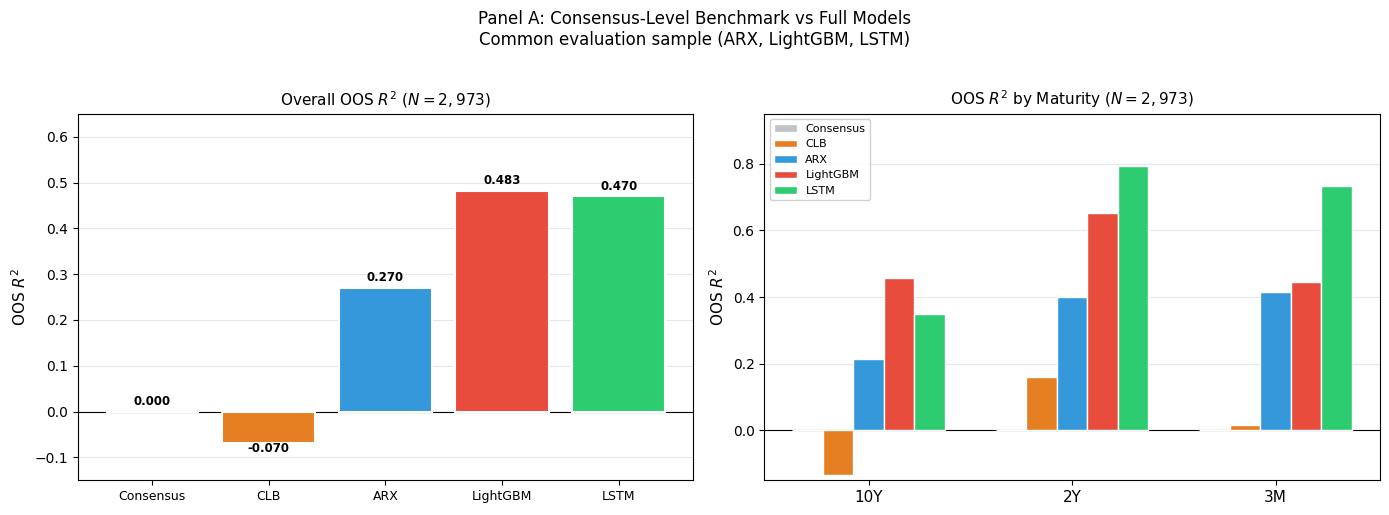

Saved: clb_comparison_common.png


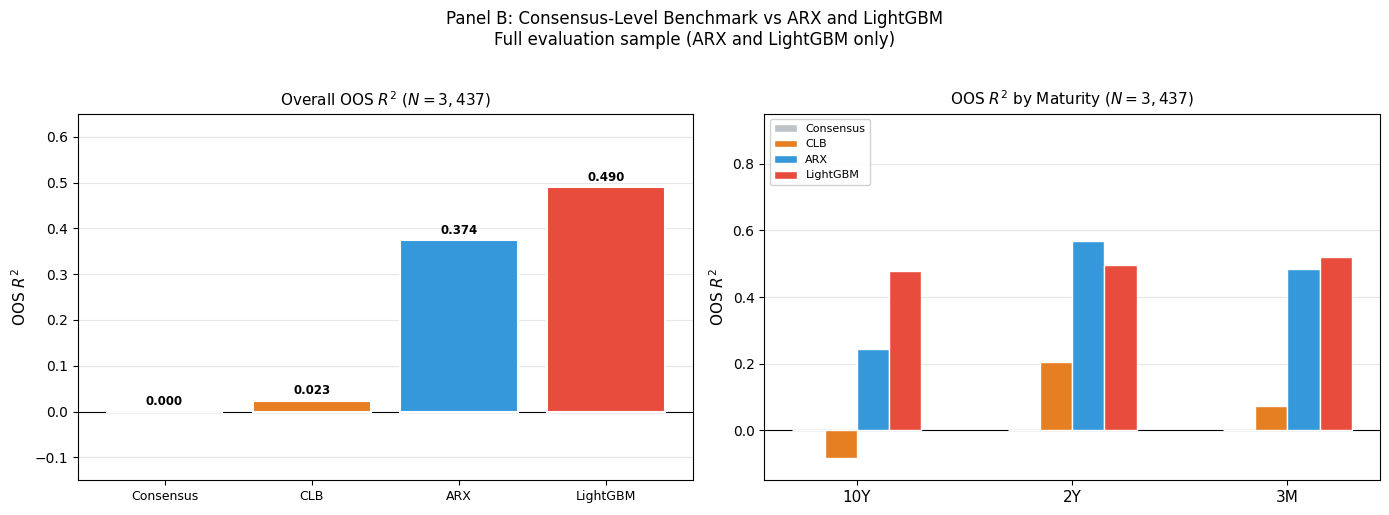

Saved: clb_comparison_full.png


In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

base = '/Users/yuzetsai/Desktop/Machine Learning on MacroEcon/Data/'

clb  = pd.read_csv(base + 'clb_predictions.csv')
arx  = pd.read_csv(base + 'arx_predictions.csv')
lgbm = pd.read_csv(base + 'lgbm_predictions.csv')
lstm = pd.read_csv(base + 'lstm_predictions_L4_equal.csv')

for df in [clb, arx, lgbm, lstm]:
    df['forecast_date'] = pd.to_datetime(df['forecast_date'])

def oos_r2(e_realized, e_hat):
    return 1 - np.mean((e_realized - e_hat)**2) / np.mean(e_realized**2)

key_cols = ['country', 'tenor', 'forecast_date', 'horizon_months']

# ── 共同樣本（N=2,973）──────────────────────────────────────
common = clb.merge(arx[key_cols + ['e_hat_arx']], on=key_cols, how='inner')
common = common.merge(lgbm[key_cols + ['e_hat_lgbm']], on=key_cols, how='inner')
common = common.merge(
    lstm[key_cols + ['e_hat']].rename(columns={'e_hat': 'e_hat_lstm'}),
    on=key_cols, how='inner')
print(f"共同樣本 N: {len(common)}")

# ── 完整樣本（N=3,437）──────────────────────────────────────
full = clb.merge(arx[key_cols + ['e_hat_arx']], on=key_cols, how='inner')
full = full.merge(lgbm[key_cols + ['e_hat_lgbm']], on=key_cols, how='inner')
print(f"完整樣本 N: {len(full)}")

# ── 計算函數 ─────────────────────────────────────────────────
def compute_r2s(df, cols_map, tenors=['10Y', '2Y', '3M']):
    overall = {}
    by_tenor = {name: {} for name in cols_map}

    for name, col in cols_map.items():
        if col is None:
            overall[name] = 0.0
            for t in tenors:
                by_tenor[name][t] = 0.0
        else:
            overall[name] = oos_r2(df['e_realized'].values, df[col].values)
            for t in tenors:
                sub = df[df['tenor'] == t]
                by_tenor[name][t] = oos_r2(
                    sub['e_realized'].values, sub[col].values)

    return overall, by_tenor

# 共同樣本的模型
cols_common = {
    'Consensus': None,
    'CLB': 'e_hat_clb',
    'ARX': 'e_hat_arx',
    'LightGBM': 'e_hat_lgbm',
    'LSTM': 'e_hat_lstm',
}

# 完整樣本的模型（無 LSTM）
cols_full = {
    'Consensus': None,
    'CLB': 'e_hat_clb',
    'ARX': 'e_hat_arx',
    'LightGBM': 'e_hat_lgbm',
}

r2_common_overall, r2_common_tenor = compute_r2s(common, cols_common)
r2_full_overall,   r2_full_tenor   = compute_r2s(full,   cols_full)

# ── 畫圖函數 ─────────────────────────────────────────────────
def plot_clb(ax_left, ax_right, r2_overall, r2_tenor,
             colors, model_names, title, n_label):

    tenors = ['10Y', '2Y', '3M']

    # Panel Left: Overall
    bars = ax_left.bar(range(len(model_names)),
                       [r2_overall[n] for n in model_names],
                       color=colors[:len(model_names)],
                       edgecolor='white', linewidth=1.5, zorder=3)

    for bar, name in zip(bars, model_names):
        val = r2_overall[name]
        offset = 0.008 if val >= 0 else -0.025
        ax_left.text(bar.get_x() + bar.get_width()/2,
                     val + offset,
                     f'{val:.3f}',
                     ha='center', va='bottom', fontsize=8.5,
                     fontweight='bold')

    ax_left.set_xticks(range(len(model_names)))
    ax_left.set_xticklabels(model_names, fontsize=9)
    ax_left.set_ylabel('OOS $R^2$', fontsize=11)
    ax_left.set_title(f'Overall OOS $R^2$ ({n_label})', fontsize=11)
    ax_left.set_ylim(-0.15, 0.65)
    ax_left.axhline(0, color='black', linewidth=0.8)
    ax_left.grid(axis='y', alpha=0.3, zorder=0)

    # Panel Right: By Tenor
    x = np.arange(len(tenors))
    width = 0.15
    for i, (name, color) in enumerate(zip(model_names, colors)):
        vals = [r2_tenor[name][t] for t in tenors]
        offset = (i - (len(model_names)-1)/2) * width
        ax_right.bar(x + offset, vals, width,
                     label=name, color=color,
                     edgecolor='white', linewidth=1.0, zorder=3)

    ax_right.set_xticks(x)
    ax_right.set_xticklabels(tenors, fontsize=11)
    ax_right.set_ylabel('OOS $R^2$', fontsize=11)
    ax_right.set_title(f'OOS $R^2$ by Maturity ({n_label})', fontsize=11)
    ax_right.axhline(0, color='black', linewidth=0.8)
    ax_right.grid(axis='y', alpha=0.3, zorder=0)
    ax_right.legend(loc='upper left', fontsize=8, framealpha=0.9)
    ax_right.set_ylim(-0.15, 0.95)

# ── 畫兩張圖 ─────────────────────────────────────────────────
colors_5 = ['#bdc3c7', '#e67e22', '#3498db', '#e74c3c', '#2ecc71']
colors_4 = ['#bdc3c7', '#e67e22', '#3498db', '#e74c3c']

# 圖 A：共同樣本（N=2,973）
fig1, axes1 = plt.subplots(1, 2, figsize=(14, 5))
plot_clb(axes1[0], axes1[1],
         r2_common_overall, r2_common_tenor,
         colors_5, list(cols_common.keys()),
         'Common Sample', f'$N = {len(common):,}$')
plt.suptitle('Panel A: Consensus-Level Benchmark vs Full Models\n'
             'Common evaluation sample (ARX, LightGBM, LSTM)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(base + 'clb_comparison_common.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: clb_comparison_common.png")

# 圖 B：完整樣本（N=3,437）
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
plot_clb(axes2[0], axes2[1],
         r2_full_overall, r2_full_tenor,
         colors_4, list(cols_full.keys()),
         'Full Sample', f'$N = {len(full):,}$')
plt.suptitle('Panel B: Consensus-Level Benchmark vs ARX and LightGBM\n'
             'Full evaluation sample (ARX and LightGBM only)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(base + 'clb_comparison_full.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: clb_comparison_full.png")

### Lightgbm


In [4]:
# ============================================================
# LightGBM Rolling Window Pipeline
# 主要設計：B 等權 + CV 調參 + Early Stopping
# ============================================================

import pandas as pd
import numpy as np
import lightgbm as lgb
from itertools import product
import warnings
warnings.filterwarnings('ignore')

# ── 1. 讀資料 ────────────────────────────────────────────────
df = pd.read_csv('/Users/yuzetsai/Desktop/Machine Learning on MacroEcon/Data/panel_main_macro_merged.csv')
df['forecast_date'] = pd.to_datetime(df['forecast_date'])
df = df.sort_values('forecast_date').reset_index(drop=True)

# ── 2. Dummies ───────────────────────────────────────────────
df['tenor_dummy_2Y'] = (df['tenor'] == '2Y').astype(int)
df['tenor_dummy_3M'] = (df['tenor'] == '3M').astype(int)
for h in [3, 6, 9, 12, 18]:
    df[f'horizon_{h}'] = (df['horizon_months'] == h).astype(int)

# ── 3. 特徵集 ────────────────────────────────────────────────
BASE_FEATURES = [
    'current_yield_t', 'bbg_consensus_tph', 'forecast_revision', 'bbg_consensus_lag1',
    'us_10y_rate', 'us_2y_rate',
    'local_gdp_qoq_fcst', 'local_cpi_qoq_fcst', 'local_ca_qoq_fcst',
    'us_gdp_qoq_fcst', 'us_cpi_qoq_fcst', 'us_ca_qoq_fcst',
    'VIX_Index', 'CO1_Comdty', 'SPX_Index', 'fx_usd_local',
    'tenor_dummy_2Y', 'tenor_dummy_3M',
    'horizon_3', 'horizon_6', 'horizon_9', 'horizon_12', 'horizon_18'
]

FEATURES_WITH_MISSING = [
    'current_yield_t', 'bbg_consensus_lag1', 'forecast_revision',
    'local_gdp_qoq_fcst', 'local_cpi_qoq_fcst', 'local_ca_qoq_fcst',
    'fx_usd_local', 'us_2y_rate'
]

for col in FEATURES_WITH_MISSING:
    df[f'{col}_missing'] = df[col].isna().astype(int)

MISSING_INDICATORS = [f'{col}_missing' for col in FEATURES_WITH_MISSING]
ALL_FEATURES = BASE_FEATURES + MISSING_INDICATORS

# ── 4. 加權方案 ──────────────────────────────────────────────
tenor_counts = df['tenor'].value_counts()
total        = len(df)

inv_weights  = {t: (1/c) / sum(1/c for c in tenor_counts)
                for t, c in tenor_counts.items()}
df['w_inverse'] = df['tenor'].map(inv_weights)

prop_weights = {t: c/total for t, c in tenor_counts.items()}
df['w_prop'] = df['tenor'].map(prop_weights)

# ── 5. 評估函數 ──────────────────────────────────────────────
def oos_r2(e_realized, e_hat):
    mse_model     = np.mean((e_realized - e_hat) ** 2)
    mse_consensus = np.mean(e_realized ** 2)
    return 1 - mse_model / mse_consensus

def full_metrics(e_realized, e_hat):
    mse      = np.mean((e_realized - e_hat) ** 2)
    rmse     = np.sqrt(mse)
    mae      = np.mean(np.abs(e_realized - e_hat))
    r2       = oos_r2(e_realized, e_hat)
    mse_con  = np.mean(e_realized ** 2)
    rmse_con = np.sqrt(mse_con)
    mae_con  = np.mean(np.abs(e_realized))
    return {
        'OOS_R2'   : round(r2,       4),
        'MSE'      : round(mse,      4),
        'RMSE'     : round(rmse,     4),
        'MAE'      : round(mae,      4),
        'MSE_con'  : round(mse_con,  4),
        'RMSE_con' : round(rmse_con, 4),
        'MAE_con'  : round(mae_con,  4),
        'N'        : len(e_realized)
    }

def eval_report(pred_df, col_hat, label):
    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")

    m = full_metrics(pred_df['e_realized'], pred_df[col_hat])
    print(f"\nOverall:")
    print(f"  OOS R²={m['OOS_R2']:.4f} | MSE={m['MSE']:.4f} | "
          f"RMSE={m['RMSE']:.4f} | MAE={m['MAE']:.4f} | N={m['N']}")
    print(f"  [Consensus] MSE={m['MSE_con']:.4f} | "
          f"RMSE={m['RMSE_con']:.4f} | MAE={m['MAE_con']:.4f}")

    print("\nBy Tenor:")
    for tenor in ['10Y', '2Y', '3M']:
        sub = pred_df[pred_df['tenor'] == tenor]
        if len(sub) == 0: continue
        m = full_metrics(sub['e_realized'], sub[col_hat])
        print(f"  {tenor:4s} | OOS R²={m['OOS_R2']:.4f} | "
              f"MSE={m['MSE']:.4f} | RMSE={m['RMSE']:.4f} | "
              f"MAE={m['MAE']:.4f} | N={m['N']}")

    print("\nBy Horizon:")
    for h in [3, 6, 9, 12, 18, 24]:
        sub = pred_df[pred_df['horizon_months'] == h]
        if len(sub) == 0: continue
        m = full_metrics(sub['e_realized'], sub[col_hat])
        print(f"  {h:2d}M | OOS R²={m['OOS_R2']:.4f} | "
              f"MSE={m['MSE']:.4f} | RMSE={m['RMSE']:.4f} | "
              f"MAE={m['MAE']:.4f} | N={m['N']}")

    print("\nTenor × Horizon OOS R²:")
    pivot = pred_df.groupby(['tenor', 'horizon_months']).apply(
        lambda x: round(oos_r2(x['e_realized'], x[col_hat]), 4)
    ).unstack()
    print(pivot)

# ── 6. 超參數網格 ────────────────────────────────────────────
param_grid = {
    'learning_rate' : [0.01, 0.05, 0.1],
    'num_leaves'    : [15, 31, 63],
    'n_estimators'  : [100, 200, 500],
}

all_combinations = list(product(
    param_grid['learning_rate'],
    param_grid['num_leaves'],
    param_grid['n_estimators']
))
print(f"超參數組合數: {len(all_combinations)}")

# ── 7. Rolling Window ────────────────────────────────────────
forecast_dates = sorted(df['forecast_date'].unique())
MIN_TRAIN_SIZE  = 200
VAL_RATIO       = 0.2
predictions     = []
best_params_log = []

for i, t in enumerate(forecast_dates):

    train = df[df['forecast_date'] < t].copy()
    test  = df[df['forecast_date'] == t].copy()

    if len(train) < MIN_TRAIN_SIZE:
        continue

    # 缺失值填補
    for col in FEATURES_WITH_MISSING:
        median_val = train[col].median()
        train[col] = train[col].fillna(median_val)
        test[col]  = test[col].fillna(median_val)

    # train / val 切分（時序，後 20% 作為 val）
    val_size  = max(int(len(train) * VAL_RATIO), 10)
    train_fit = train.iloc[:-val_size].copy()
    val_fit   = train.iloc[-val_size:].copy()

    X_train_fit = train_fit[ALL_FEATURES].values
    y_train_fit = train_fit['target_error_e'].values
    X_val       = val_fit[ALL_FEATURES].values
    y_val       = val_fit['target_error_e'].values
    X_test      = test[ALL_FEATURES].values
    y_test      = test['target_error_e'].values

    # ── CV 調參（等權）────────────────────────────────────────
    best_mse    = np.inf
    best_params = None

    for lr, nl, ne in all_combinations:
        params = {
            'objective'        : 'regression',
            'metric'           : 'mse',
            'learning_rate'    : lr,
            'num_leaves'       : nl,
            'n_estimators'     : ne,
            'min_child_samples': 20,
            'subsample'        : 0.8,
            'colsample_bytree' : 0.8,
            'reg_alpha'        : 0.1,
            'reg_lambda'       : 0.1,
            'random_state'     : 42,
            'verbose'          : -1
        }
        try:
            model = lgb.LGBMRegressor(**params)
            model.fit(
                X_train_fit, y_train_fit,
                eval_set=[(X_val, y_val)],
                callbacks=[lgb.early_stopping(20, verbose=False),
                           lgb.log_evaluation(-1)]
            )
            val_pred = model.predict(X_val)
            val_mse  = np.mean((y_val - val_pred) ** 2)
            if val_mse < best_mse:
                best_mse    = val_mse
                best_params = params.copy()
        except:
            continue

    if best_params is None:
        continue

    best_params_log.append({
        'forecast_date'  : t,
        'learning_rate'  : best_params['learning_rate'],
        'num_leaves'     : best_params['num_leaves'],
        'n_estimators'   : best_params['n_estimators'],
        'val_mse'        : round(best_mse, 4)
    })

    # ── 用最佳超參數在完整 train 上重新訓練 ──────────────────
    preds = {}

    # B 等權（主要）
    try:
        model_B = lgb.LGBMRegressor(**best_params)
        model_B.fit(
            train[ALL_FEATURES].values,
            train['target_error_e'].values,
            callbacks=[lgb.log_evaluation(-1)]
        )
        preds['B'] = model_B.predict(X_test)
    except:
        preds['B'] = np.full(len(test), np.nan)

    # A 反頻率（robustness）
    try:
        model_A = lgb.LGBMRegressor(**best_params)
        model_A.fit(
            train[ALL_FEATURES].values,
            train['target_error_e'].values,
            sample_weight=train['w_inverse'].values,
            callbacks=[lgb.log_evaluation(-1)]
        )
        preds['A'] = model_A.predict(X_test)
    except:
        preds['A'] = np.full(len(test), np.nan)

    # C 正頻率（參考）
    try:
        model_C = lgb.LGBMRegressor(**best_params)
        model_C.fit(
            train[ALL_FEATURES].values,
            train['target_error_e'].values,
            sample_weight=train['w_prop'].values,
            callbacks=[lgb.log_evaluation(-1)]
        )
        preds['C'] = model_C.predict(X_test)
    except:
        preds['C'] = np.full(len(test), np.nan)

    for j in range(len(test)):
        predictions.append({
            'country'         : test['country'].iloc[j],
            'tenor'           : test['tenor'].iloc[j],
            'forecast_date'   : t,
            'horizon_months'  : test['horizon_months'].iloc[j],
            'e_realized'      : y_test[j],
            'e_hat_lgbm'      : preds['B'][j],
            'e_hat_lgbm_inv'  : preds['A'][j],
            'e_hat_lgbm_prop' : preds['C'][j],
        })

    if i % 5 == 0:
        print(f"[{i+1:2d}/{len(forecast_dates)}] {t.date()} | "
              f"train_n={len(train)} | "
              f"best: lr={best_params['learning_rate']} "
              f"nl={best_params['num_leaves']} "
              f"ne={best_params['n_estimators']} "
              f"val_mse={best_mse:.4f}")

pred_df = pd.DataFrame(predictions)
print(f"\nDone. Total predictions: {len(pred_df)}")

# ── 8. 報告結果 ───────────────────────────────────────────────
eval_report(pred_df, 'e_hat_lgbm',      'LightGBM — 主要（等權）')
eval_report(pred_df, 'e_hat_lgbm_inv',  'LightGBM — Robustness（反頻率）')
eval_report(pred_df, 'e_hat_lgbm_prop', 'LightGBM — 參考（正頻率）')

# ── 9. 儲存結果與超參數記錄 ───────────────────────────────────
pred_df.to_csv(
    '/Users/yuzetsai/Desktop/Machine Learning on MacroEcon/Data/lgbm_predictions.csv',
    index=False)

params_df = pd.DataFrame(best_params_log)
params_df.to_csv(
    '/Users/yuzetsai/Desktop/Machine Learning on MacroEcon/Data/lgbm_best_params.csv',
    index=False)

print("\nSaved: lgbm_predictions.csv")
print("Saved: lgbm_best_params.csv")

# ── 10. 超參數選擇分析 ────────────────────────────────────────
print("\n=== 最佳超參數分布 ===")
print("\nLearning Rate:")
print(params_df['learning_rate'].value_counts().sort_index())
print("\nNum Leaves:")
print(params_df['num_leaves'].value_counts().sort_index())
print("\nN Estimators:")
print(params_df['n_estimators'].value_counts().sort_index())

超參數組合數: 27
[11/66] 2011-09-30 | train_n=255 | best: lr=0.01 nl=15 ne=500 val_mse=0.8105
[16/66] 2012-12-31 | train_n=401 | best: lr=0.05 nl=15 ne=100 val_mse=0.7454
[21/66] 2014-03-31 | train_n=546 | best: lr=0.1 nl=15 ne=500 val_mse=0.8046
[26/66] 2015-06-30 | train_n=725 | best: lr=0.1 nl=15 ne=500 val_mse=0.5406
[31/66] 2016-09-30 | train_n=883 | best: lr=0.1 nl=31 ne=100 val_mse=0.2343
[36/66] 2017-12-29 | train_n=1109 | best: lr=0.05 nl=15 ne=100 val_mse=0.7099
[41/66] 2019-03-29 | train_n=1510 | best: lr=0.1 nl=63 ne=500 val_mse=0.5620
[46/66] 2020-06-30 | train_n=1954 | best: lr=0.1 nl=15 ne=500 val_mse=2.2959
[51/66] 2021-09-30 | train_n=2411 | best: lr=0.1 nl=15 ne=500 val_mse=3.4974
[56/66] 2022-12-30 | train_n=2851 | best: lr=0.05 nl=63 ne=100 val_mse=3.5658
[61/66] 2024-03-29 | train_n=3318 | best: lr=0.01 nl=15 ne=100 val_mse=3.3710
[66/66] 2025-06-30 | train_n=3645 | best: lr=0.1 nl=15 ne=200 val_mse=7.0419

Done. Total predictions: 3437

  LightGBM — 主要（等權）

Overall:
  O


=== 整體特徵重要性（mean |SHAP|）===
bbg_consensus_tph             0.4325
us_2y_rate                    0.3740
SPX_Index                     0.3550
us_10y_rate                   0.2295
local_cpi_qoq_fcst            0.2119
current_yield_t               0.2101
CO1_Comdty                    0.2044
local_ca_qoq_fcst             0.1815
fx_usd_local                  0.1746
us_gdp_qoq_fcst               0.1152
bbg_consensus_lag1            0.1000
forecast_revision             0.0897
us_cpi_qoq_fcst               0.0482
us_ca_qoq_fcst                0.0473
local_gdp_qoq_fcst            0.0454
VIX_Index                     0.0351
tenor_dummy_3M                0.0260
horizon_3                     0.0141
tenor_dummy_2Y                0.0108
current_yield_t_missing       0.0081
bbg_consensus_lag1_missing    0.0063
horizon_12                    0.0051
local_gdp_qoq_fcst_missing    0.0049
fx_usd_local_missing          0.0017
horizon_18                    0.0016
local_cpi_qoq_fcst_missing    0.0015
horizon_6

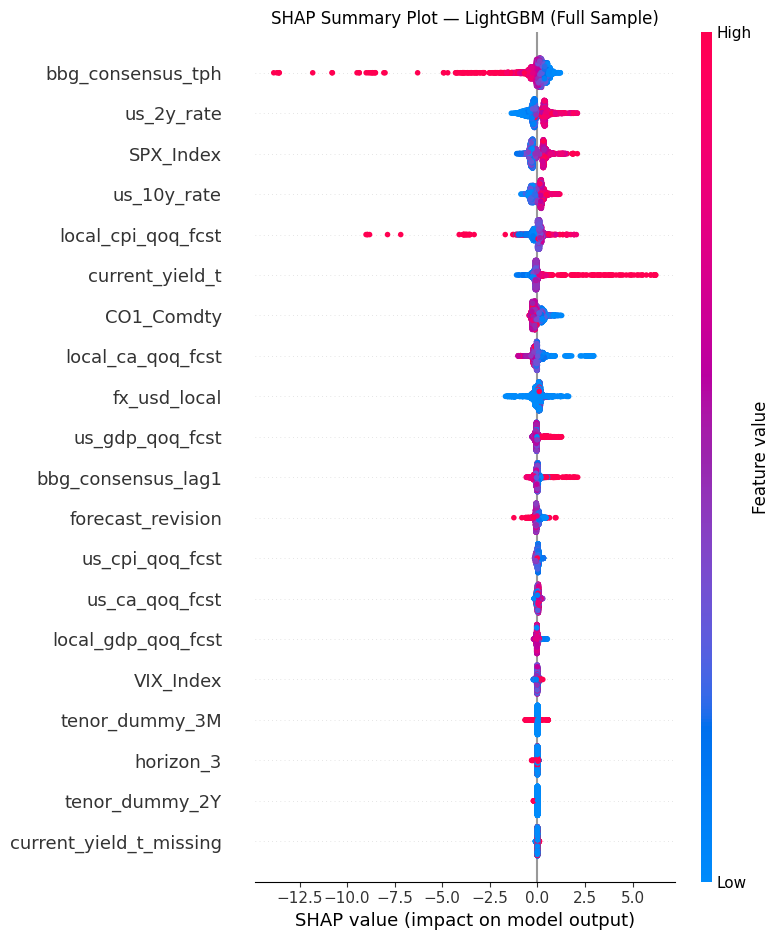

Saved: shap_summary_overall.png


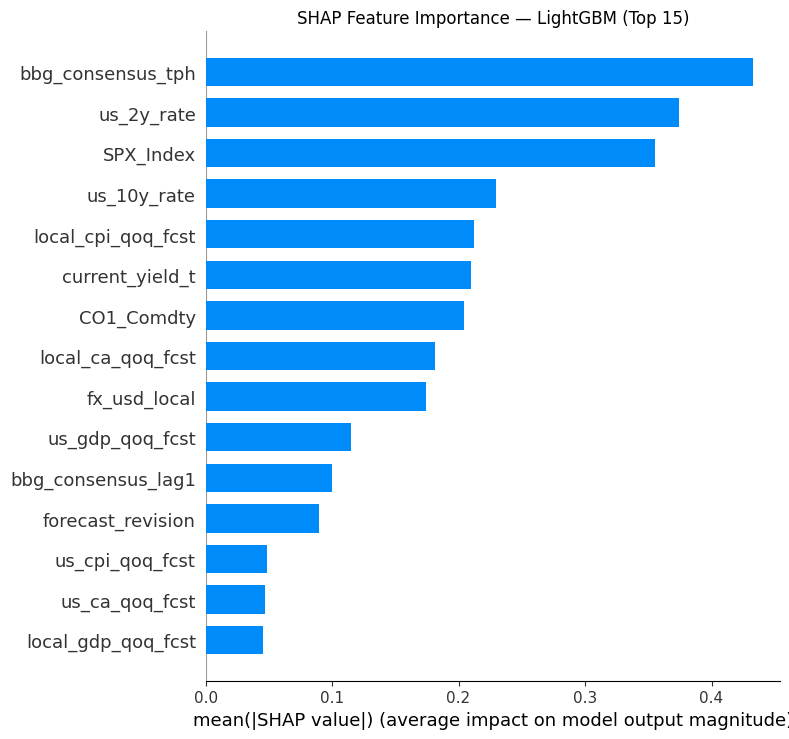

Saved: shap_bar_overall.png

=== Top 10 特徵重要性：10Y ===
bbg_consensus_tph     0.4099
SPX_Index             0.3561
us_2y_rate            0.3535
us_10y_rate           0.2199
current_yield_t       0.2191
CO1_Comdty            0.1938
local_cpi_qoq_fcst    0.1854
fx_usd_local          0.1799
local_ca_qoq_fcst     0.1790
us_gdp_qoq_fcst       0.1023


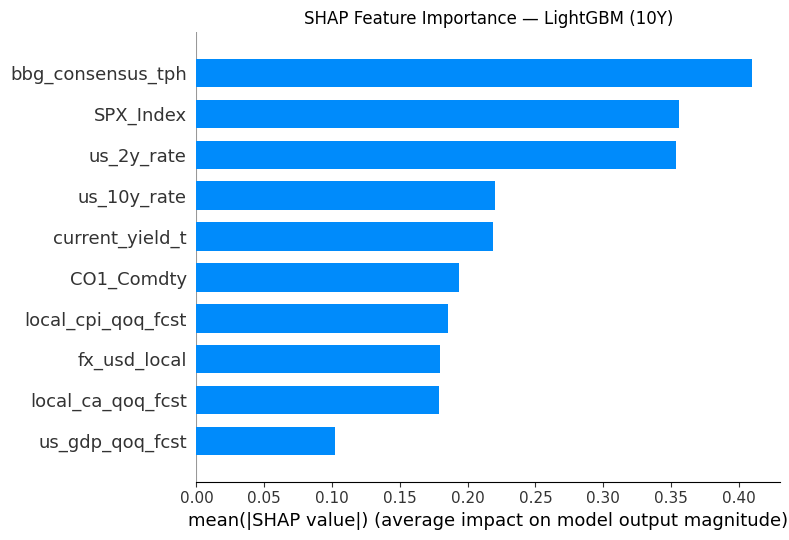

Saved: shap_bar_10Y.png

=== Top 10 特徵重要性：2Y ===
bbg_consensus_tph     0.4779
us_2y_rate            0.4479
SPX_Index             0.3224
local_cpi_qoq_fcst    0.2903
CO1_Comdty            0.2550
us_10y_rate           0.2525
us_gdp_qoq_fcst       0.1621
current_yield_t       0.1591
fx_usd_local          0.1308
local_ca_qoq_fcst     0.1064


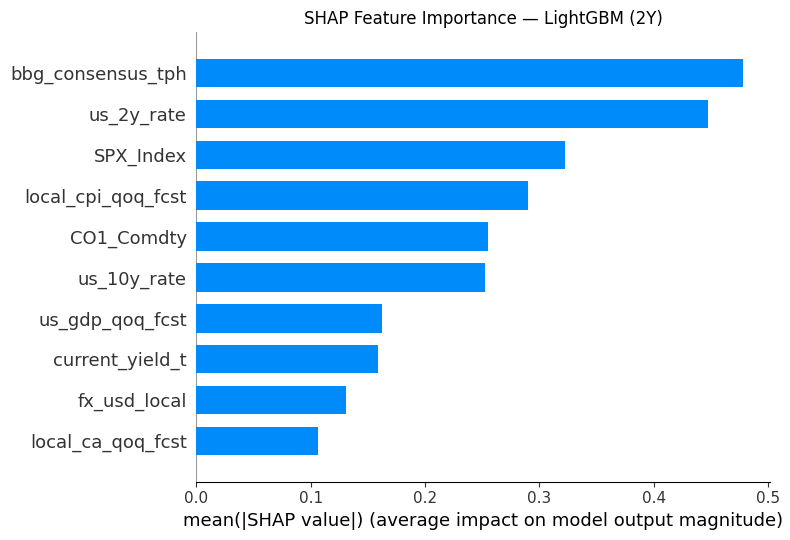

Saved: shap_bar_2Y.png

=== Top 10 特徵重要性：3M ===
bbg_consensus_tph     0.6021
us_2y_rate            0.4732
SPX_Index             0.3976
local_cpi_qoq_fcst    0.3687
local_ca_qoq_fcst     0.3333
us_10y_rate           0.2949
CO1_Comdty            0.2354
current_yield_t       0.1980
fx_usd_local          0.1903
us_gdp_qoq_fcst       0.1773


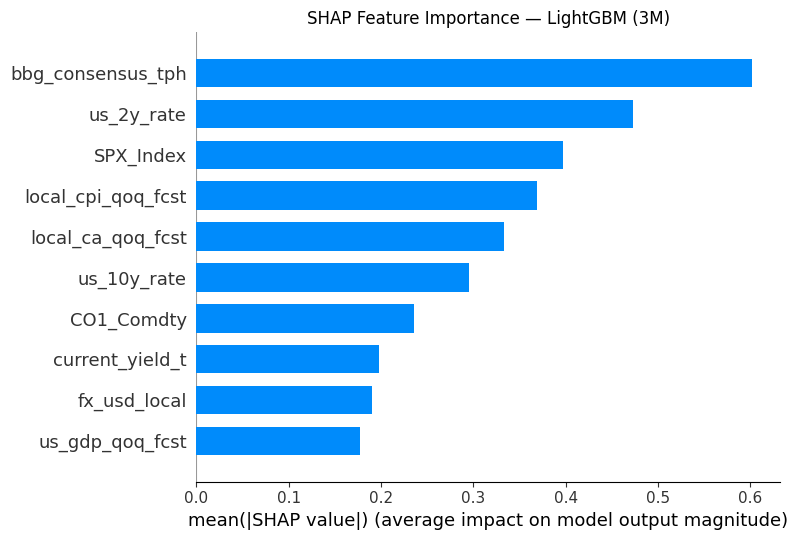

Saved: shap_bar_3M.png

Saved: shap_values.csv


In [6]:
# ============================================================
# SHAP Analysis — LightGBM
# ============================================================

import shap
import matplotlib.pyplot as plt

# ── 1. 用最後一個 rolling window 的模型做 SHAP ───────────────
# 重新訓練最後一期的模型（用完整 train）
last_t     = forecast_dates[-1]
train_last = df[df['forecast_date'] < last_t].copy()

for col in FEATURES_WITH_MISSING:
    median_val = train_last[col].median()
    train_last[col] = train_last[col].fillna(median_val)

# 用 lgbm_best_params.csv 的最後一筆超參數
last_params = {
    'objective'        : 'regression',
    'metric'           : 'mse',
    'learning_rate'    : params_df.iloc[-1]['learning_rate'],
    'num_leaves'       : int(params_df.iloc[-1]['num_leaves']),
    'n_estimators'     : int(params_df.iloc[-1]['n_estimators']),
    'min_child_samples': 20,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 0.1,
    'random_state'     : 42,
    'verbose'          : -1
}

shap_model = lgb.LGBMRegressor(**last_params)
shap_model.fit(
    train_last[ALL_FEATURES].values,
    train_last['target_error_e'].values,
    callbacks=[lgb.log_evaluation(-1)]
)

# ── 2. 計算 SHAP values ──────────────────────────────────────
explainer   = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(train_last[ALL_FEATURES].values)
shap_df     = pd.DataFrame(shap_values, columns=ALL_FEATURES)

# ── 3. 整體特徵重要性（mean |SHAP|）─────────────────────────
mean_shap = shap_df.abs().mean().sort_values(ascending=False)
print("\n=== 整體特徵重要性（mean |SHAP|）===")
print(mean_shap.round(4).to_string())

# ── 4. Summary Plot（整體）──────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    train_last[ALL_FEATURES],
    feature_names=ALL_FEATURES,
    show=False
)
plt.title('SHAP Summary Plot — LightGBM (Full Sample)')
plt.tight_layout()
plt.savefig('/Users/yuzetsai/Desktop/Machine Learning on MacroEcon/Data/shap_summary_overall.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_summary_overall.png")

# ── 5. Bar Plot（整體，前 15 個特徵）────────────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    train_last[ALL_FEATURES],
    feature_names=ALL_FEATURES,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('SHAP Feature Importance — LightGBM (Top 15)')
plt.tight_layout()
plt.savefig('/Users/yuzetsai/Desktop/Machine Learning on MacroEcon/Data/shap_bar_overall.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_bar_overall.png")

# ── 6. 分 Tenor 的 SHAP（前 10 個特徵）─────────────────────
for tenor in ['10Y', '2Y', '3M']:
    sub_idx = train_last[train_last['tenor'] == tenor].index
    sub_idx_local = train_last.index.get_indexer(sub_idx)

    if len(sub_idx_local) == 0:
        continue

    shap_sub = shap_values[sub_idx_local]
    X_sub    = train_last[ALL_FEATURES].iloc[sub_idx_local]

    mean_shap_sub = pd.Series(
        np.abs(shap_sub).mean(axis=0),
        index=ALL_FEATURES
    ).sort_values(ascending=False)

    print(f"\n=== Top 10 特徵重要性：{tenor} ===")
    print(mean_shap_sub.head(10).round(4).to_string())

    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        shap_sub, X_sub,
        feature_names=ALL_FEATURES,
        plot_type='bar',
        max_display=10,
        show=False
    )
    plt.title(f'SHAP Feature Importance — LightGBM ({tenor})')
    plt.tight_layout()
    plt.savefig(
        f'/Users/yuzetsai/Desktop/Machine Learning on MacroEcon/Data/shap_bar_{tenor}.png',
        dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: shap_bar_{tenor}.png")

# ── 7. 儲存 SHAP 數值 ────────────────────────────────────────
shap_df['tenor']          = train_last['tenor'].values
shap_df['horizon_months'] = train_last['horizon_months'].values
shap_df['country']        = train_last['country'].values
shap_df.to_csv(
    '/Users/yuzetsai/Desktop/Machine Learning on MacroEcon/Data/shap_values.csv',
    index=False)
print("\nSaved: shap_values.csv")

### LSTM


In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices())
# 應該看到 [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
#            PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [10]:
# ============================================================
# LSTM Rolling Window Pipeline
# L = 2, 4, 6 × 三個加權版本 = 9 個版本
# ============================================================

import random
import numpy as np
import os
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')


# ── 3. 特徵集 ────────────────────────────────────────────────
BASE_FEATURES = [
    'current_yield_t', 'bbg_consensus_tph', 'forecast_revision', 'bbg_consensus_lag1',
    'us_10y_rate', 'us_2y_rate',
    'local_gdp_qoq_fcst', 'local_cpi_qoq_fcst', 'local_ca_qoq_fcst',
    'us_gdp_qoq_fcst', 'us_cpi_qoq_fcst', 'us_ca_qoq_fcst',
    'VIX_Index', 'CO1_Comdty', 'SPX_Index', 'fx_usd_local',
    'tenor_dummy_2Y', 'tenor_dummy_3M',
    'horizon_3', 'horizon_6', 'horizon_9', 'horizon_12', 'horizon_18'
]

FEATURES_WITH_MISSING = [
    'current_yield_t', 'bbg_consensus_lag1', 'forecast_revision',
    'local_gdp_qoq_fcst', 'local_cpi_qoq_fcst', 'local_ca_qoq_fcst',
    'fx_usd_local', 'us_2y_rate'
]

for col in FEATURES_WITH_MISSING:
    df[f'{col}_missing'] = df[col].isna().astype(int)

MISSING_INDICATORS = [f'{col}_missing' for col in FEATURES_WITH_MISSING]
ALL_FEATURES = BASE_FEATURES + MISSING_INDICATORS
N_FEATURES   = len(ALL_FEATURES)
print(f"Number of features: {N_FEATURES}")

# ── 4. 加權方案 ──────────────────────────────────────────────
tenor_counts = df['tenor'].value_counts()
total        = len(df)

inv_weights  = {t: (1/c) / sum(1/c for c in tenor_counts)
                for t, c in tenor_counts.items()}
df['w_inverse'] = df['tenor'].map(inv_weights)

prop_weights = {t: c/total for t, c in tenor_counts.items()}
df['w_prop'] = df['tenor'].map(prop_weights)

# ── 5. 評估函數 ──────────────────────────────────────────────
def oos_r2(e_realized, e_hat):
    mse_model     = np.mean((e_realized - e_hat) ** 2)
    mse_consensus = np.mean(e_realized ** 2)
    return 1 - mse_model / mse_consensus

def full_metrics(e_realized, e_hat):
    mse      = np.mean((e_realized - e_hat) ** 2)
    rmse     = np.sqrt(mse)
    mae      = np.mean(np.abs(e_realized - e_hat))
    r2       = oos_r2(e_realized, e_hat)
    mse_con  = np.mean(e_realized ** 2)
    rmse_con = np.sqrt(mse_con)
    mae_con  = np.mean(np.abs(e_realized))
    return {
        'OOS_R2'   : round(r2,       4),
        'MSE'      : round(mse,      4),
        'RMSE'     : round(rmse,     4),
        'MAE'      : round(mae,      4),
        'MSE_con'  : round(mse_con,  4),
        'RMSE_con' : round(rmse_con, 4),
        'MAE_con'  : round(mae_con,  4),
        'N'        : len(e_realized)
    }

def eval_report(pred_df, col_hat, label):
    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")

    m = full_metrics(pred_df['e_realized'], pred_df[col_hat])
    print(f"\nOverall:")
    print(f"  OOS R²={m['OOS_R2']:.4f} | MSE={m['MSE']:.4f} | "
          f"RMSE={m['RMSE']:.4f} | MAE={m['MAE']:.4f} | N={m['N']}")
    print(f"  [Consensus] MSE={m['MSE_con']:.4f} | "
          f"RMSE={m['RMSE_con']:.4f} | MAE={m['MAE_con']:.4f}")

    print("\nBy Tenor:")
    for tenor in ['10Y', '2Y', '3M']:
        sub = pred_df[pred_df['tenor'] == tenor]
        if len(sub) == 0: continue
        m = full_metrics(sub['e_realized'], sub[col_hat])
        print(f"  {tenor:4s} | OOS R²={m['OOS_R2']:.4f} | "
              f"MSE={m['MSE']:.4f} | RMSE={m['RMSE']:.4f} | "
              f"MAE={m['MAE']:.4f} | N={m['N']}")

    print("\nBy Horizon:")
    for h in [3, 6, 9, 12, 18, 24]:
        sub = pred_df[pred_df['horizon_months'] == h]
        if len(sub) == 0: continue
        m = full_metrics(sub['e_realized'], sub[col_hat])
        print(f"  {h:2d}M | OOS R²={m['OOS_R2']:.4f} | "
              f"MSE={m['MSE']:.4f} | RMSE={m['RMSE']:.4f} | "
              f"MAE={m['MAE']:.4f} | N={m['N']}")

    print("\nTenor × Horizon OOS R²:")
    pivot = pred_df.groupby(['tenor', 'horizon_months']).apply(
        lambda x: round(oos_r2(x['e_realized'], x[col_hat]), 4)
    ).unstack()
    print(pivot)

# ── 6. LSTM 模型建構函數 ─────────────────────────────────────
def build_lstm(n_features, seq_len):
    tf.random.set_seed(SEED)
    model = keras.Sequential([
        layers.Input(shape=(seq_len, n_features)),
        layers.LSTM(64, return_sequences=True,
                    dropout=0.2, recurrent_dropout=0.0),
        layers.LSTM(64, return_sequences=False,
                    dropout=0.2, recurrent_dropout=0.0),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse'
    )
    return model

# ── 7. 序列建構函數 ──────────────────────────────────────────
def build_sequences(data, seq_len, feature_cols, target_col,
                    weight_col=None):
    """
    對每筆觀測，在同一個 country × tenor × horizon 內
    找過去 seq_len 期的歷史，組成序列
    """
    sequences = []
    targets   = []
    weights   = []
    indices   = []

    groups = data.groupby(['country', 'tenor', 'horizon_months'])

    for (country, tenor, horizon), group in groups:
        group = group.sort_values('forecast_date').reset_index(drop=True)

        for i in range(seq_len - 1, len(group)):
            seq   = group[feature_cols].iloc[i-seq_len+1:i+1].values
            target = group[target_col].iloc[i]
            idx    = group.index[i]

            if np.any(np.isnan(seq)):
                continue

            sequences.append(seq)
            targets.append(target)
            indices.append(idx)

            if weight_col is not None:
                weights.append(group[weight_col].iloc[i])
            else:
                weights.append(1.0)

    if len(sequences) == 0:
        return None, None, None, None

    X = np.array(sequences, dtype=np.float32)
    y = np.array(targets,   dtype=np.float32)
    w = np.array(weights,   dtype=np.float32)

    return X, y, w, indices

# ── 8. Rolling Window ────────────────────────────────────────
forecast_dates = sorted(df['forecast_date'].unique())
MIN_TRAIN_SIZE = 200
VAL_RATIO      = 0.2
SEQ_LENGTHS    = [2, 4, 6]

df['forecast_date'] = pd.to_datetime(df['forecast_date'])
forecast_dates = sorted(df['forecast_date'].unique())

# 儲存所有版本的預測結果
all_predictions = {}
for L in SEQ_LENGTHS:
    for w_name in ['equal', 'inverse', 'prop']:
        all_predictions[f'L{L}_{w_name}'] = []

for i, t in enumerate(forecast_dates):

    train_raw = df[df['forecast_date'] < t].copy()
    test_raw  = df[df['forecast_date'] == t].copy()

    if len(train_raw) < MIN_TRAIN_SIZE:
        continue

    # 缺失值填補（用 train 中位數）
    for col in FEATURES_WITH_MISSING:
        median_val = train_raw[col].median()
        train_raw[col] = train_raw[col].fillna(median_val)
        test_raw[col]  = test_raw[col].fillna(median_val)

    # Standardization（用 train fit）
    scaler = StandardScaler()
    train_raw[ALL_FEATURES] = scaler.fit_transform(
        train_raw[ALL_FEATURES].values)
    test_raw[ALL_FEATURES]  = scaler.transform(
        test_raw[ALL_FEATURES].values)

    if i % 10 == 0:
        print(f"\n[{i+1:2d}/{len(forecast_dates)}] {t.date()} | "
              f"train_n={len(train_raw)}")

    for L in SEQ_LENGTHS:

        # 建構訓練序列（等權）
        X_tr_eq, y_tr, w_eq, _ = build_sequences(
            train_raw, L, ALL_FEATURES, 'target_error_e',
            weight_col=None)

        if X_tr_eq is None or len(X_tr_eq) < 20:
            continue

        # val split（後 20%）
        val_size    = max(int(len(X_tr_eq) * VAL_RATIO), 10)
        X_val       = X_tr_eq[-val_size:]
        y_val       = y_tr[-val_size:]
        X_tr_fit    = X_tr_eq[:-val_size]
        y_tr_fit    = y_tr[:-val_size]

        # 建構測試序列
        # 對 test 的每筆觀測，從 train 末尾取歷史
        test_sequences = []
        test_meta      = []

        for _, row in test_raw.iterrows():
            c  = row['country']
            m  = row['tenor']
            h  = row['horizon_months']

            hist = train_raw[
                (train_raw['country']        == c) &
                (train_raw['tenor']          == m) &
                (train_raw['horizon_months'] == h)
            ].sort_values('forecast_date').tail(L)

            if len(hist) < L:
                continue

            seq = hist[ALL_FEATURES].values
            if np.any(np.isnan(seq)):
                continue

            test_sequences.append(seq)
            test_meta.append({
                'country'       : c,
                'tenor'         : m,
                'forecast_date' : t,
                'horizon_months': h,
                'e_realized'    : row['target_error_e'],
                'w_inverse'     : row['w_inverse'],
                'w_prop'        : row['w_prop'],
            })

        if len(test_sequences) == 0:
            continue

        X_test = np.array(test_sequences, dtype=np.float32)

        # 三個加權版本
        weight_configs = {
            'equal'  : np.ones(len(X_tr_eq)),
            'inverse': build_sequences(
                train_raw, L, ALL_FEATURES, 'target_error_e',
                weight_col='w_inverse')[2],
            'prop'   : build_sequences(
                train_raw, L, ALL_FEATURES, 'target_error_e',
                weight_col='w_prop')[2],
        }

        for w_name, w_train in weight_configs.items():
            if w_train is None:
                continue

            tf.random.set_seed(SEED)
            model = build_lstm(N_FEATURES, L)

            early_stop = keras.callbacks.EarlyStopping(
                monitor='val_loss',
                patience=10,
                restore_best_weights=True,
                verbose=0
            )

            model.fit(
                X_tr_eq, y_tr,
                sample_weight=w_train,
                validation_data=(X_val, y_val),
                epochs=50,
                batch_size=32,
                callbacks=[early_stop],
                verbose=0
            )

            preds = model.predict(X_test, verbose=0).flatten()

            for j, meta in enumerate(test_meta):
                all_predictions[f'L{L}_{w_name}'].append({
                    **meta,
                    'e_hat': preds[j]
                })

            # 清理記憶體
            del model
            keras.backend.clear_session()

        if i % 10 == 0:
            print(f"  L={L} done | test_n={len(test_sequences)}")

print("\n=== All rolling windows done ===")

# ── 9. 整理結果 ──────────────────────────────────────────────
results_dfs = {}
for key, preds in all_predictions.items():
    if len(preds) == 0:
        print(f"Warning: {key} has no predictions")
        continue
    results_dfs[key] = pd.DataFrame(preds)
    print(f"{key}: {len(results_dfs[key])} predictions")

# ── 10. 報告主要結果（L=4 等權）─────────────────────────────
print("\n\n=== 主要結果：L=4 等權 ===")
if 'L4_equal' in results_dfs:
    eval_report(results_dfs['L4_equal'], 'e_hat', 'LSTM L=4 — 主要（等權）')

# ── 11. 消融實驗：L = 2, 4, 6（等權）────────────────────────
print("\n\n=== 消融實驗：序列長度（等權）===")
print(f"\n{'L':4s} | {'Overall':8s} | {'10Y':8s} | {'2Y':8s} | {'3M':8s}")
print("-" * 45)
for L in SEQ_LENGTHS:
    key = f'L{L}_equal'
    if key not in results_dfs:
        continue
    pdf = results_dfs[key]
    r_all = oos_r2(pdf['e_realized'], pdf['e_hat'])
    r_10y = oos_r2(pdf[pdf['tenor']=='10Y']['e_realized'],
                   pdf[pdf['tenor']=='10Y']['e_hat'])
    r_2y  = oos_r2(pdf[pdf['tenor']=='2Y']['e_realized'],
                   pdf[pdf['tenor']=='2Y']['e_hat'])
    r_3m  = oos_r2(pdf[pdf['tenor']=='3M']['e_realized'],
                   pdf[pdf['tenor']=='3M']['e_hat'])
    print(f"L={L} | {r_all:8.4f} | {r_10y:8.4f} | {r_2y:8.4f} | {r_3m:8.4f}")

# ── 12. 三個加權版本（L=4）──────────────────────────────────
print("\n\n=== 加權方案比較：L=4 ===")
for w_name in ['equal', 'inverse', 'prop']:
    key = f'L4_{w_name}'
    if key not in results_dfs:
        continue
    label = {'equal': '等權', 'inverse': '反頻率', 'prop': '正頻率'}[w_name]
    eval_report(results_dfs[key], 'e_hat', f'LSTM L=4 — {label}')

# ── 13. 儲存 ─────────────────────────────────────────────────
base_path = '/Users/yuzetsai/Desktop/Machine Learning on MacroEcon/Data/'

for key, pdf in results_dfs.items():
    fname = f'lstm_predictions_{key}.csv'
    pdf.to_csv(base_path + fname, index=False)
    print(f"Saved: {fname}")

print("\nAll done!")

Number of features: 31

[11/66] 2011-09-30 | train_n=255
  L=2 done | test_n=27
  L=4 done | test_n=26
  L=6 done | test_n=23

[21/66] 2014-03-31 | train_n=546
  L=2 done | test_n=32
  L=4 done | test_n=29
  L=6 done | test_n=28

[31/66] 2016-09-30 | train_n=883
  L=2 done | test_n=32
  L=4 done | test_n=30
  L=6 done | test_n=25

[41/66] 2019-03-29 | train_n=1510
  L=2 done | test_n=77
  L=4 done | test_n=73
  L=6 done | test_n=62

[51/66] 2021-09-30 | train_n=2411
  L=2 done | test_n=88
  L=4 done | test_n=85
  L=6 done | test_n=74

[61/66] 2024-03-29 | train_n=3318
  L=2 done | test_n=86
  L=4 done | test_n=85
  L=6 done | test_n=83

=== All rolling windows done ===
L2_equal: 3193 predictions
L2_inverse: 3193 predictions
L2_prop: 3193 predictions
L4_equal: 2973 predictions
L4_inverse: 2973 predictions
L4_prop: 2973 predictions
L6_equal: 2756 predictions
L6_inverse: 2756 predictions
L6_prop: 2756 predictions


=== 主要結果：L=4 等權 ===

  LSTM L=4 — 主要（等權）

Overall:
  OOS R²=0.4697 | MSE=1

In [22]:
# ============================================================
# Block Bootstrap: OOS R² Confidence Intervals
# ============================================================

import numpy as np
import pandas as pd

base = '/Users/yuzetsai/Desktop/Machine Learning on MacroEcon/Data/'

# ── 讀資料 ───────────────────────────────────────────────────
arx  = pd.read_csv(base + 'arx_predictions.csv')
lgbm = pd.read_csv(base + 'lgbm_predictions.csv')
lstm = pd.read_csv(base + 'lstm_predictions_L4_equal.csv')

for df in [arx, lgbm, lstm]:
    df['forecast_date'] = pd.to_datetime(df['forecast_date'])

# ── 合併共同樣本 ─────────────────────────────────────────────
key_cols = ['country', 'tenor', 'forecast_date', 'horizon_months']
merged = arx.merge(lgbm[key_cols + ['e_hat_lgbm']], on=key_cols, how='inner')
merged = merged.merge(
    lstm[key_cols + ['e_hat']].rename(columns={'e_hat': 'e_hat_lstm'}),
    on=key_cols, how='inner')
print(f"共同樣本 N: {len(merged)}")

# ── Block Bootstrap 函數 ─────────────────────────────────────
def block_bootstrap_oos_r2(e_realized, e_hat,
                            n_boot=1000, block_size=8, seed=42):
    """
    Block bootstrap for OOS R²
    block_size=8 對應約 2 年的季度資料
    """
    np.random.seed(seed)
    n = len(e_realized)
    r2_boots = []

    for _ in range(n_boot):
        indices = []
        while len(indices) < n:
            start = np.random.randint(0, n - block_size + 1)
            indices.extend(range(start, start + block_size))
        indices = np.array(indices[:n])

        e_r_boot = e_realized[indices]
        e_h_boot = e_hat[indices]

        mse_model = np.mean((e_r_boot - e_h_boot) ** 2)
        mse_bench = np.mean(e_r_boot ** 2)
        r2_boots.append(1 - mse_model / mse_bench)

    return {
        'mean'  : round(np.mean(r2_boots),              4),
        'se'    : round(np.std(r2_boots),               4),
        'ci_lo' : round(np.percentile(r2_boots, 2.5),   4),
        'ci_hi' : round(np.percentile(r2_boots, 97.5),  4),
    }

# ── 執行 Bootstrap ───────────────────────────────────────────
models = {
    'ARX'      : merged['e_hat_arx'].values,
    'LightGBM' : merged['e_hat_lgbm'].values,
    'LSTM'     : merged['e_hat_lstm'].values,
}

print("\n=== Block Bootstrap OOS R² (N_boot=1000, block_size=8) ===")
print(f"\n{'':12s} | {'OOS R²':8s} | {'SE':6s} | {'95% CI':15s}")
print("-" * 50)

results = {}
for name, e_hat in models.items():
    res = block_bootstrap_oos_r2(
        merged['e_realized'].values, e_hat)
    results[name] = res
    print(f"{name:12s} | {res['mean']:8.4f} | {res['se']:6.4f} | "
          f"[{res['ci_lo']:.4f}, {res['ci_hi']:.4f}]")

# ── By Tenor ────────────────────────────────────────────────
print("\n=== By Tenor ===")
for tenor in ['10Y', '2Y', '3M']:
    sub = merged[merged['tenor'] == tenor]
    print(f"\nTenor: {tenor} (N={len(sub)})")
    print(f"{'':12s} | {'OOS R²':8s} | {'SE':6s} | {'95% CI':15s}")
    print("-" * 50)
    for name, _ in models.items():
        col = {'ARX': 'e_hat_arx',
               'LightGBM': 'e_hat_lgbm',
               'LSTM': 'e_hat_lstm'}[name]
        res = block_bootstrap_oos_r2(
            sub['e_realized'].values,
            sub[col].values)
        print(f"{name:12s} | {res['mean']:8.4f} | {res['se']:6.4f} | "
              f"[{res['ci_lo']:.4f}, {res['ci_hi']:.4f}]")

# ── By Horizon ───────────────────────────────────────────────
print("\n=== By Horizon ===")
for h in [3, 6, 9, 12, 18, 24]:
    sub = merged[merged['horizon_months'] == h]
    print(f"\nHorizon: {h}M (N={len(sub)})")
    print(f"{'':12s} | {'OOS R²':8s} | {'SE':6s} | {'95% CI':15s}")
    print("-" * 50)
    for name, _ in models.items():
        col = {'ARX': 'e_hat_arx',
               'LightGBM': 'e_hat_lgbm',
               'LSTM': 'e_hat_lstm'}[name]
        res = block_bootstrap_oos_r2(
            sub['e_realized'].values,
            sub[col].values,
            block_size=4)  # 子樣本用較小的 block
        print(f"{name:12s} | {res['mean']:8.4f} | {res['se']:6.4f} | "
              f"[{res['ci_lo']:.4f}, {res['ci_hi']:.4f}]")


共同樣本 N: 2973

=== Block Bootstrap OOS R² (N_boot=1000, block_size=8) ===

             | OOS R²   | SE     | 95% CI         
--------------------------------------------------
ARX          |   0.2642 | 0.0576 | [0.1465, 0.3707]
LightGBM     |   0.4798 | 0.0456 | [0.3843, 0.5656]
LSTM         |   0.4684 | 0.0830 | [0.2862, 0.6112]

=== By Tenor ===

Tenor: 10Y (N=2483)
             | OOS R²   | SE     | 95% CI         
--------------------------------------------------
ARX          |   0.2014 | 0.0666 | [0.0585, 0.3188]
LightGBM     |   0.4565 | 0.0459 | [0.3647, 0.5473]
LSTM         |   0.3406 | 0.1040 | [0.1301, 0.5275]

Tenor: 2Y (N=317)
             | OOS R²   | SE     | 95% CI         
--------------------------------------------------
ARX          |   0.2665 | 0.3220 | [-0.5440, 0.5955]
LightGBM     |   0.5931 | 0.1588 | [0.1884, 0.7487]
LSTM         |   0.7271 | 0.1381 | [0.4068, 0.8835]

Tenor: 3M (N=173)
             | OOS R²   | SE     | 95% CI         
-----------------------

In [ ]:
# ============================================================
# Section 5.6: Crisis vs. Non-Crisis Analysis
# ============================================================

import pandas as pd
import numpy as np

# ── 1. 讀原始資料（取 VIX）────────────────────────────────────
df = pd.read_csv('/Users/yuzetsai/Desktop/Machine Learning on MacroEcon/Data/panel_main_macro_merged.csv')
df['forecast_date'] = pd.to_datetime(df['forecast_date'])

# 每個 forecast_date 的 VIX（取平均，因為同一 forecast_date 有多筆）
vix_map = df.groupby('forecast_date')['VIX_Index'].mean().reset_index()
vix_map.columns = ['forecast_date', 'VIX']

print("VIX 分布：")
print(vix_map['VIX'].describe().round(2))
print(f"\n中位數：{vix_map['VIX'].median():.2f}")
print(f"第75百分位：{vix_map['VIX'].quantile(0.75):.2f}")

# ── 2. 門檻設定 ──────────────────────────────────────────────
VIX_MEDIAN = vix_map['VIX'].median()
VIX_P75    = vix_map['VIX'].quantile(0.75)

# ── 3. 讀預測結果 ────────────────────────────────────────────
base = '/Users/yuzetsai/Desktop/Machine Learning on MacroEcon/Data/'

arx  = pd.read_csv(base + 'arx_predictions.csv')
lgbm = pd.read_csv(base + 'lgbm_predictions.csv')
lstm = pd.read_csv(base + 'lstm_predictions_L4_equal.csv')

arx['forecast_date']  = pd.to_datetime(arx['forecast_date'])
lgbm['forecast_date'] = pd.to_datetime(lgbm['forecast_date'])
lstm['forecast_date'] = pd.to_datetime(lstm['forecast_date'])

# merge VIX
arx  = arx.merge(vix_map,  on='forecast_date', how='left')
lgbm = lgbm.merge(vix_map, on='forecast_date', how='left')
lstm = lstm.merge(vix_map, on='forecast_date', how='left')

# ── 4. OOS R² 函數 ───────────────────────────────────────────
def oos_r2(e_realized, e_hat):
    mse_model     = np.mean((e_realized - e_hat) ** 2)
    mse_consensus = np.mean(e_realized ** 2)
    return 1 - mse_model / mse_consensus

# ── 5. Crisis vs. Non-Crisis 分析 ────────────────────────────
def crisis_analysis(pred_df, col_hat, label, threshold, threshold_name):
    low  = pred_df[pred_df['VIX'] <= threshold]
    high = pred_df[pred_df['VIX'] >  threshold]

    print(f"\n--- {label} | 門檻：{threshold_name} (VIX={threshold:.2f}) ---")
    print(f"{'':20s} | {'Low VIX':10s} | {'High VIX':10s} | {'N(Low)':8s} | {'N(High)':8s}")
    print("-" * 65)

    # Overall
    r_low  = oos_r2(low['e_realized'],  low[col_hat])
    r_high = oos_r2(high['e_realized'], high[col_hat])
    print(f"{'Overall':20s} | {r_low:10.4f} | {r_high:10.4f} | {len(low):8d} | {len(high):8d}")

    # By Tenor
    for tenor in ['10Y', '2Y', '3M']:
        sl = low[low['tenor']  == tenor]
        sh = high[high['tenor'] == tenor]
        if len(sl) == 0 or len(sh) == 0: continue
        r_l = oos_r2(sl['e_realized'], sl[col_hat])
        r_h = oos_r2(sh['e_realized'], sh[col_hat])
        print(f"{'Tenor '+tenor:20s} | {r_l:10.4f} | {r_h:10.4f} | {len(sl):8d} | {len(sh):8d}")

    # By Horizon
    for h in [3, 6, 9, 12, 18, 24]:
        sl = low[low['horizon_months']  == h]
        sh = high[high['horizon_months'] == h]
        if len(sl) == 0 or len(sh) == 0: continue
        r_l = oos_r2(sl['e_realized'], sl[col_hat])
        r_h = oos_r2(sh['e_realized'], sh[col_hat])
        print(f"{'Horizon '+str(h)+'M':20s} | {r_l:10.4f} | {r_h:10.4f} | {len(sl):8d} | {len(sh):8d}")

# ── 6. 跑分析 ────────────────────────────────────────────────
for threshold, name in [(VIX_MEDIAN, '中位數'), (VIX_P75, 'P75')]:
    print(f"\n{'='*65}")
    print(f"VIX 門檻：{name} = {threshold:.2f}")
    print(f"{'='*65}")

    crisis_analysis(arx,  'e_hat_arx',  'ARX',       threshold, name)
    crisis_analysis(lgbm, 'e_hat_lgbm', 'LightGBM',  threshold, name)
    crisis_analysis(lstm, 'e_hat',      'LSTM L=4',  threshold, name)

VIX 分布：
count    66.00
mean     19.05
std       6.48
min      10.15
25%      14.68
50%      17.14
75%      23.35
max      45.13
Name: VIX, dtype: float64

中位數：17.14
第75百分位：23.35

VIX 門檻：中位數 = 17.14

--- ARX | 門檻：中位數 (VIX=17.14) ---
                     | Low VIX    | High VIX   | N(Low)   | N(High) 
-----------------------------------------------------------------
Overall              |     0.4320 |     0.3113 |     1888 |     1549
Tenor 10Y            |     0.3093 |     0.1670 |     1580 |     1142
Tenor 2Y             |     0.6312 |     0.4725 |      185 |      269
Tenor 3M             |     0.5239 |     0.4751 |      123 |      138
Horizon 3M           |     0.6046 |     0.4657 |      395 |      312
Horizon 6M           |     0.3897 |     0.0098 |      395 |      292
Horizon 9M           |     0.4246 |     0.1856 |      394 |      270
Horizon 12M          |     0.3345 |     0.3133 |      367 |      274
Horizon 18M          |     0.3060 |     0.3963 |      186 |      207
Horizon 24M 

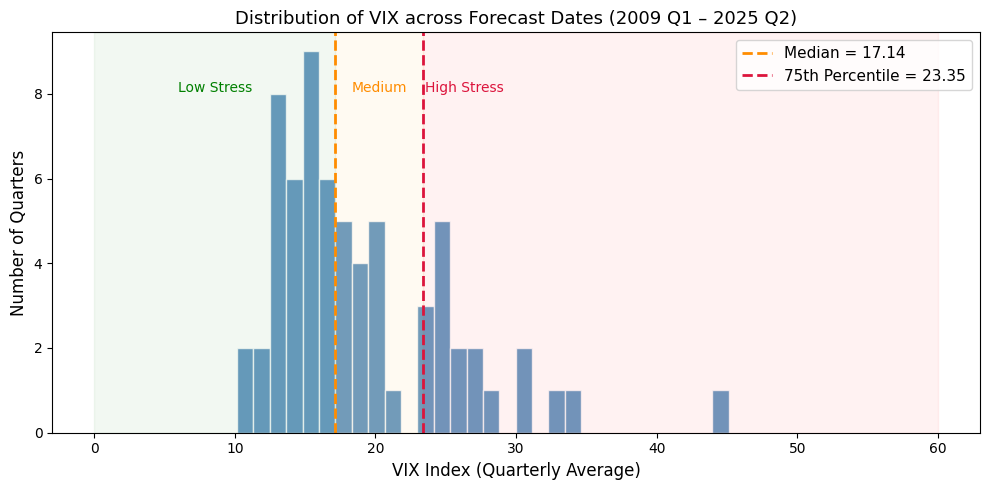

Saved: vix_distribution.png


In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── VIX 分布圖 ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(vix_map['VIX'], bins=30, color='steelblue', 
        edgecolor='white', alpha=0.8)

# 中位數線
ax.axvline(VIX_MEDIAN, color='darkorange', linewidth=2, 
           linestyle='--', label=f'Median = {VIX_MEDIAN:.2f}')

# P75 線
ax.axvline(VIX_P75, color='crimson', linewidth=2,
           linestyle='--', label=f'75th Percentile = {VIX_P75:.2f}')

# 標注幾個重要事件
events = {
    'GFC\n(2008-Q4)' : ('2008-10-01', 45),
    'COVID\n(2020-Q1)': ('2020-03-31', 45),
    'Taper\n(2013-Q2)': ('2013-06-30', 20),
}

ax.set_xlabel('VIX Index (Quarterly Average)', fontsize=12)
ax.set_ylabel('Number of Quarters', fontsize=12)
ax.set_title('Distribution of VIX across Forecast Dates (2009 Q1 – 2025 Q2)',
             fontsize=13)
ax.legend(fontsize=11)

# 標注分區
ax.axvspan(0, VIX_MEDIAN, alpha=0.05, color='green', label='Low stress')
ax.axvspan(VIX_MEDIAN, VIX_P75, alpha=0.05, color='orange')
ax.axvspan(VIX_P75, 60, alpha=0.05, color='red')

# 文字標注
ax.text(VIX_MEDIAN/2, ax.get_ylim()[1]*0.85, 
        'Low Stress', ha='center', color='green', fontsize=10)
ax.text((VIX_MEDIAN + VIX_P75)/2, ax.get_ylim()[1]*0.85,
        'Medium', ha='center', color='darkorange', fontsize=10)
ax.text(VIX_P75 + 3, ax.get_ylim()[1]*0.85,
        'High Stress', ha='center', color='crimson', fontsize=10)

plt.tight_layout()
plt.savefig(
    '/Users/yuzetsai/Desktop/Machine Learning on MacroEcon/Data/vix_distribution.png',
    dpi=150, bbox_inches='tight')
plt.show()
print("Saved: vix_distribution.png")

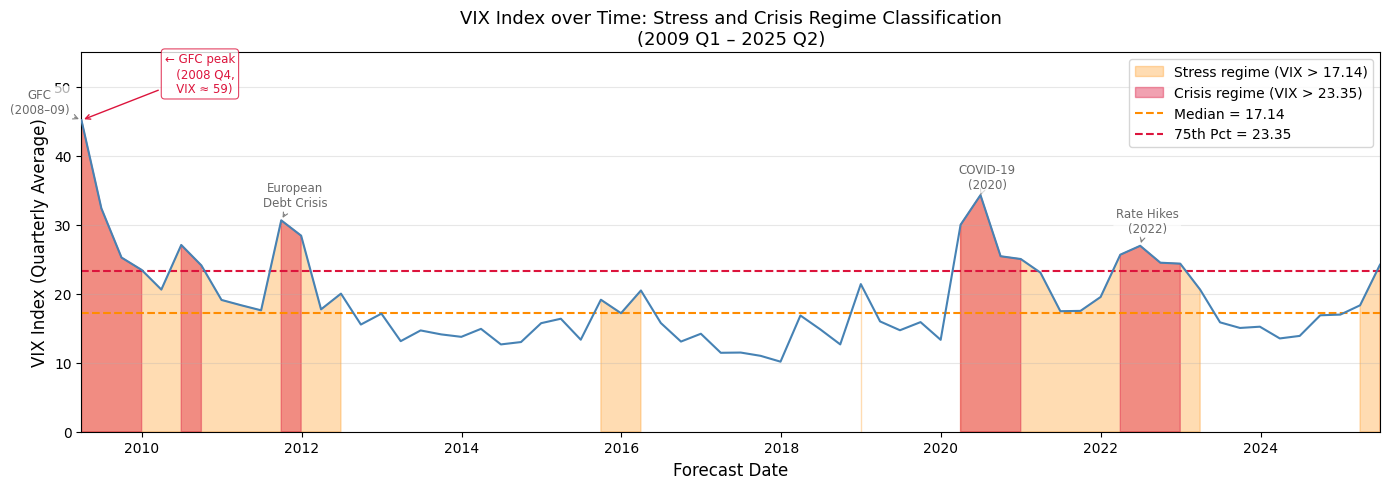

Saved: vix_timeseries.png


In [8]:
fig, ax = plt.subplots(figsize=(14, 5))

# 畫 VIX 走勢
ax.plot(vix_map['forecast_date'], vix_map['VIX'],
        color='steelblue', linewidth=1.5, zorder=3)

# 填色
ax.fill_between(vix_map['forecast_date'], vix_map['VIX'],
                where=vix_map['VIX'] > VIX_MEDIAN,
                color='darkorange', alpha=0.3,
                label=f'Stress regime (VIX > {VIX_MEDIAN:.2f})')

ax.fill_between(vix_map['forecast_date'], vix_map['VIX'],
                where=vix_map['VIX'] > VIX_P75,
                color='crimson', alpha=0.4,
                label=f'Crisis regime (VIX > {VIX_P75:.2f})')

# 門檻線
ax.axhline(VIX_MEDIAN, color='darkorange', linewidth=1.5,
           linestyle='--', label=f'Median = {VIX_MEDIAN:.2f}')
ax.axhline(VIX_P75, color='crimson', linewidth=1.5,
           linestyle='--', label=f'75th Pct = {VIX_P75:.2f}')

# ── 事件標注 ─────────────────────────────────────────────────
events = [
    # (date, label, xytext offset)
    ('2009-03-31', 'GFC\n(2008–09)',        (-30, 5)),
    ('2011-09-30', 'European\nDebt Crisis', (10, 10)),
    ('2020-06-30', 'COVID-19\n(2020)',      (5, 5)),
    ('2022-06-30', 'Rate Hikes\n(2022)',    (5, 10)),
]

for date, label, offset in events:
    dt = pd.to_datetime(date)
    # 找最近的 forecast_date
    idx = (vix_map['forecast_date'] - dt).abs().argmin()
    dt_actual  = vix_map['forecast_date'].iloc[idx]
    vix_actual = vix_map['VIX'].iloc[idx]

    ax.annotate(
        label,
        xy=(dt_actual, vix_actual),
        xytext=(offset[0], offset[1]),
        textcoords='offset points',
        ha='center', fontsize=8.5,
        color='dimgray',
        arrowprops=dict(arrowstyle='->', color='gray', lw=0.8),
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='none')
    )

# ── GFC 額外說明（因為樣本從 2009 開始，最高點在樣本外）────────
ax.annotate(
    '← GFC peak\n   (2008 Q4,\n   VIX ≈ 59)',
    xy=(pd.to_datetime('2009-03-31'),
        vix_map[vix_map['forecast_date'] == pd.to_datetime('2009-03-31')]['VIX'].values[0]),
    xytext=(60, 20),
    textcoords='offset points',
    ha='left', fontsize=8.5,
    color='crimson',
    arrowprops=dict(arrowstyle='->', color='crimson', lw=1.0),
    bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8, ec='crimson', lw=0.8)
)

ax.set_xlabel('Forecast Date', fontsize=12)
ax.set_ylabel('VIX Index (Quarterly Average)', fontsize=12)
ax.set_title('VIX Index over Time: Stress and Crisis Regime Classification\n(2009 Q1 – 2025 Q2)',
             fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.set_xlim(vix_map['forecast_date'].min(), vix_map['forecast_date'].max())
ax.set_ylim(0, 55)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(
    '/Users/yuzetsai/Desktop/Machine Learning on MacroEcon/Data/vix_timeseries.png',
    dpi=150, bbox_inches='tight')
plt.show()
print("Saved: vix_timeseries.png")

In [1]:
# ============================================================
# Section 5.6: Statistical Significance Tests
# Clark-West (2007) & Diebold-Mariano (1995)
# ============================================================

import pandas as pd
import numpy as np
from scipy import stats

# ── 1. 讀資料 ────────────────────────────────────────────────
base = '/Users/yuzetsai/Desktop/Machine Learning on MacroEcon/Data/'

arx  = pd.read_csv(base + 'arx_predictions.csv')
lgbm = pd.read_csv(base + 'lgbm_predictions.csv')
lstm = pd.read_csv(base + 'lstm_predictions_L4_equal.csv')

arx['forecast_date']  = pd.to_datetime(arx['forecast_date'])
lgbm['forecast_date'] = pd.to_datetime(lgbm['forecast_date'])
lstm['forecast_date'] = pd.to_datetime(lstm['forecast_date'])

# ── 2. Clark-West (2007) Test ────────────────────────────────
def clark_west_test(e_realized, e_hat_unrest):
    """
    CW test: H0: nested model (consensus, e_hat=0) performs
             as well as unrestricted model
    
    CW statistic = mean(f_t) / se(f_t)
    where f_t = e_benchmark^2 - e_model^2 + (e_benchmark - e_model)^2
              = e_realized^2 - e_model^2 + adjustment
    
    One-sided test: reject H0 if CW > 1.282 (10%), 1.645 (5%), 2.326 (1%)
    """
    e_bench = e_realized          # benchmark error = e_realized (since e_hat_bench = 0)
    e_model = e_realized - e_hat_unrest  # model error

    # CW adjustment
    f_t = e_bench**2 - e_model**2 + (e_hat_unrest)**2

    n    = len(f_t)
    mean_f = np.mean(f_t)
    se_f   = np.std(f_t, ddof=1) / np.sqrt(n)

    cw_stat = mean_f / se_f

    # one-sided p-value
    p_value = 1 - stats.norm.cdf(cw_stat)

    return {
        'CW_stat' : round(cw_stat, 3),
        'p_value' : round(p_value, 4),
        'N'       : n,
        'sig'     : '***' if p_value < 0.01 else
                    '**'  if p_value < 0.05 else
                    '*'   if p_value < 0.10 else ''
    }

# ── 3. Diebold-Mariano (1995) Test ──────────────────────────
def diebold_mariano_test(e_realized, e_hat_1, e_hat_2):
    """
    DM test: H0: model 1 and model 2 have equal predictive accuracy
    d_t = loss(model1) - loss(model2) = e1^2 - e2^2
    DM = mean(d_t) / se(d_t)
    Two-sided test
    """
    e1 = e_realized - e_hat_1
    e2 = e_realized - e_hat_2

    d_t = e1**2 - e2**2

    n      = len(d_t)
    mean_d = np.mean(d_t)
    se_d   = np.std(d_t, ddof=1) / np.sqrt(n)

    dm_stat = mean_d / se_d
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))

    return {
        'DM_stat' : round(dm_stat, 3),
        'p_value' : round(p_value, 4),
        'N'       : n,
        'sig'     : '***' if p_value < 0.01 else
                    '**'  if p_value < 0.05 else
                    '*'   if p_value < 0.10 else ''
    }

# ── 4. 合併資料（取共同觀測值）──────────────────────────────
# ARX 和 LightGBM 用相同的 key merge
key_cols = ['country', 'tenor', 'forecast_date', 'horizon_months']

merged_arx_lgbm = arx[key_cols + ['e_realized', 'e_hat_arx']].merge(
    lgbm[key_cols + ['e_hat_lgbm']],
    on=key_cols, how='inner'
)

merged_all = merged_arx_lgbm.merge(
    lstm[key_cols + ['e_hat']].rename(columns={'e_hat': 'e_hat_lstm'}),
    on=key_cols, how='inner'
)

print(f"ARX + LightGBM 共同樣本：{len(merged_arx_lgbm)}")
print(f"ARX + LightGBM + LSTM 共同樣本：{len(merged_all)}")

# ── 5. 執行檢定 ──────────────────────────────────────────────
def run_all_tests(data, label):
    print(f"\n{'='*65}")
    print(f"  {label}")
    print(f"{'='*65}")

    e_r    = data['e_realized'].values
    e_arx  = data['e_hat_arx'].values
    e_lgbm = data['e_hat_lgbm'].values

    has_lstm = 'e_hat_lstm' in data.columns
    if has_lstm:
        e_lstm = data['e_hat_lstm'].values

    # CW tests（vs Consensus）
    print(f"\n--- Clark-West Test (vs Consensus Benchmark) ---")
    print(f"{'Model':15s} | {'CW stat':8s} | {'p-value':8s} | {'Sig':4s} | {'N':6s}")
    print("-" * 55)

    for model_name, e_hat in [('ARX', e_arx),
                               ('LightGBM', e_lgbm)] + \
                              ([('LSTM', e_lstm)] if has_lstm else []):
        res = clark_west_test(e_r, e_hat)
        print(f"{model_name:15s} | {res['CW_stat']:8.3f} | "
              f"{res['p_value']:8.4f} | {res['sig']:4s} | {res['N']:6d}")

    # DM tests（between models）
    print(f"\n--- Diebold-Mariano Test (between models) ---")
    print(f"{'Comparison':25s} | {'DM stat':8s} | {'p-value':8s} | {'Sig':4s} | {'N':6s}")
    print("-" * 65)

    comparisons = [('LightGBM vs ARX', e_lgbm, e_arx)]
    if has_lstm:
        comparisons += [
            ('LSTM vs ARX',      e_lstm, e_arx),
            ('LSTM vs LightGBM', e_lstm, e_lgbm),
        ]

    for comp_name, e1, e2 in comparisons:
        res = diebold_mariano_test(e_r, e1, e2)
        print(f"{comp_name:25s} | {res['DM_stat']:8.3f} | "
              f"{res['p_value']:8.4f} | {res['sig']:4s} | {res['N']:6d}")

# ── 6. Overall ───────────────────────────────────────────────
run_all_tests(merged_all, 'Overall')

# ── 7. By Tenor ──────────────────────────────────────────────
for tenor in ['10Y', '2Y', '3M']:
    sub = merged_all[merged_all['tenor'] == tenor]
    run_all_tests(sub, f'Tenor: {tenor}')

# ── 8. By Horizon ────────────────────────────────────────────
for h in [3, 6, 9, 12, 18, 24]:
    sub = merged_all[merged_all['horizon_months'] == h]
    run_all_tests(sub, f'Horizon: {h}M')

ARX + LightGBM 共同樣本：3437
ARX + LightGBM + LSTM 共同樣本：2973

  Overall

--- Clark-West Test (vs Consensus Benchmark) ---
Model           | CW stat  | p-value  | Sig  | N     
-------------------------------------------------------
ARX             |    9.316 |   0.0000 | ***  |   2973
LightGBM        |   10.817 |   0.0000 | ***  |   2973
LSTM            |    8.602 |   0.0000 | ***  |   2973

--- Diebold-Mariano Test (between models) ---
Comparison                | DM stat  | p-value  | Sig  | N     
-----------------------------------------------------------------
LightGBM vs ARX           |   -6.330 |   0.0000 | ***  |   2973
LSTM vs ARX               |   -2.389 |   0.0169 | **   |   2973
LSTM vs LightGBM          |    0.175 |   0.8609 |      |   2973

  Tenor: 10Y

--- Clark-West Test (vs Consensus Benchmark) ---
Model           | CW stat  | p-value  | Sig  | N     
-------------------------------------------------------
ARX             |    9.935 |   0.0000 | ***  |   2483
LightGBM     

## appendix 2


In [8]:
# ============================================================
# Appendix B: Robustness — Inverse Frequency Weighting
# ============================================================

import pandas as pd
import numpy as np

base = '/Users/yuzetsai/Desktop/Machine Learning on MacroEcon/Data/'

# ── 讀資料 ───────────────────────────────────────────────────
arx  = pd.read_csv(base + 'arx_predictions.csv')
lgbm = pd.read_csv(base + 'lgbm_predictions.csv')

# ── OOS R² 函數 ──────────────────────────────────────────────
def oos_r2(e_realized, e_hat):
    mse_model     = np.mean((e_realized - e_hat) ** 2)
    mse_consensus = np.mean(e_realized ** 2)
    return 1 - mse_model / mse_consensus

def report_table(df, col_hat, label):
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")

    # Overall
    r = oos_r2(df['e_realized'], df[col_hat])
    print(f"\nOverall OOS R²: {r:.4f} | N={len(df)}")

    # By Tenor
    print("\nBy Tenor:")
    for tenor in ['10Y', '2Y', '3M']:
        sub = df[df['tenor'] == tenor]
        if len(sub) == 0: continue
        r = oos_r2(sub['e_realized'], sub[col_hat])
        print(f"  {tenor:4s} | {r:.4f} | N={len(sub)}")

    # By Horizon
    print("\nBy Horizon:")
    for h in [3, 6, 9, 12, 18, 24]:
        sub = df[df['horizon_months'] == h]
        if len(sub) == 0: continue
        r = oos_r2(sub['e_realized'], sub[col_hat])
        print(f"  {h:2d}M | {r:.4f} | N={len(sub)}")

    # Tenor × Horizon
    print("\nTenor × Horizon OOS R²:")
    pivot = df.groupby(['tenor', 'horizon_months']).apply(
        lambda x: round(oos_r2(x['e_realized'], x[col_hat]), 4)
    ).unstack()
    print(pivot)

# ── ARX 三個版本 ─────────────────────────────────────────────
report_table(arx, 'e_hat_arx',      'ARX — Equal Weight (Primary)')
report_table(arx, 'e_hat_arx_inv',  'ARX — Inverse Frequency (Robustness)')
report_table(arx, 'e_hat_arx_prop', 'ARX — Proportional (Reference)')

# ── LightGBM 三個版本 ────────────────────────────────────────
report_table(lgbm, 'e_hat_lgbm',      'LightGBM — Equal Weight (Primary)')
report_table(lgbm, 'e_hat_lgbm_inv',  'LightGBM — Inverse Frequency (Robustness)')
report_table(lgbm, 'e_hat_lgbm_prop', 'LightGBM — Proportional (Reference)')


# ── LSTM 三個版本 ────────────────────────────────────────────
lstm_eq  = pd.read_csv(base + 'lstm_predictions_L4_equal.csv')
lstm_inv = pd.read_csv(base + 'lstm_predictions_L4_inverse.csv')
lstm_prop= pd.read_csv(base + 'lstm_predictions_L4_prop.csv')

report_table(lstm_eq,   'e_hat', 'LSTM L=4 — Equal Weight (Primary)')
report_table(lstm_inv,  'e_hat', 'LSTM L=4 — Inverse Frequency (Robustness)')
report_table(lstm_prop, 'e_hat', 'LSTM L=4 — Proportional (Reference)')



  ARX — Equal Weight (Primary)

Overall OOS R²: 0.3738 | N=3437

By Tenor:
  10Y  | 0.2452 | N=2722
  2Y   | 0.5679 | N=454
  3M   | 0.4849 | N=261

By Horizon:
   3M | 0.5571 | N=707
   6M | 0.2719 | N=687
   9M | 0.3419 | N=664
  12M | 0.3253 | N=641
  18M | 0.3633 | N=393
  24M | 0.2798 | N=345

Tenor × Horizon OOS R²:
horizon_months      3       6       9       12      18      24
tenor                                                         
10Y             0.3759  0.0984  0.1815  0.2100  0.3264  0.2222
2Y              0.6884  0.5359  0.5572  0.5039  0.2458  0.1720
3M              0.2872  0.2737  0.5304  0.5015  0.5352  0.4927

  ARX — Inverse Frequency (Robustness)

Overall OOS R²: 0.2772 | N=3437

By Tenor:
  10Y  | 0.0063 | N=2722
  2Y   | 0.6415 | N=454
  3M   | 0.6093 | N=261

By Horizon:
   3M | 0.5271 | N=707
   6M | 0.0847 | N=687
   9M | 0.2387 | N=664
  12M | 0.2408 | N=641
  18M | 0.2416 | N=393
  24M | 0.1675 | N=345

Tenor × Horizon OOS R²:
horizon_months      3      

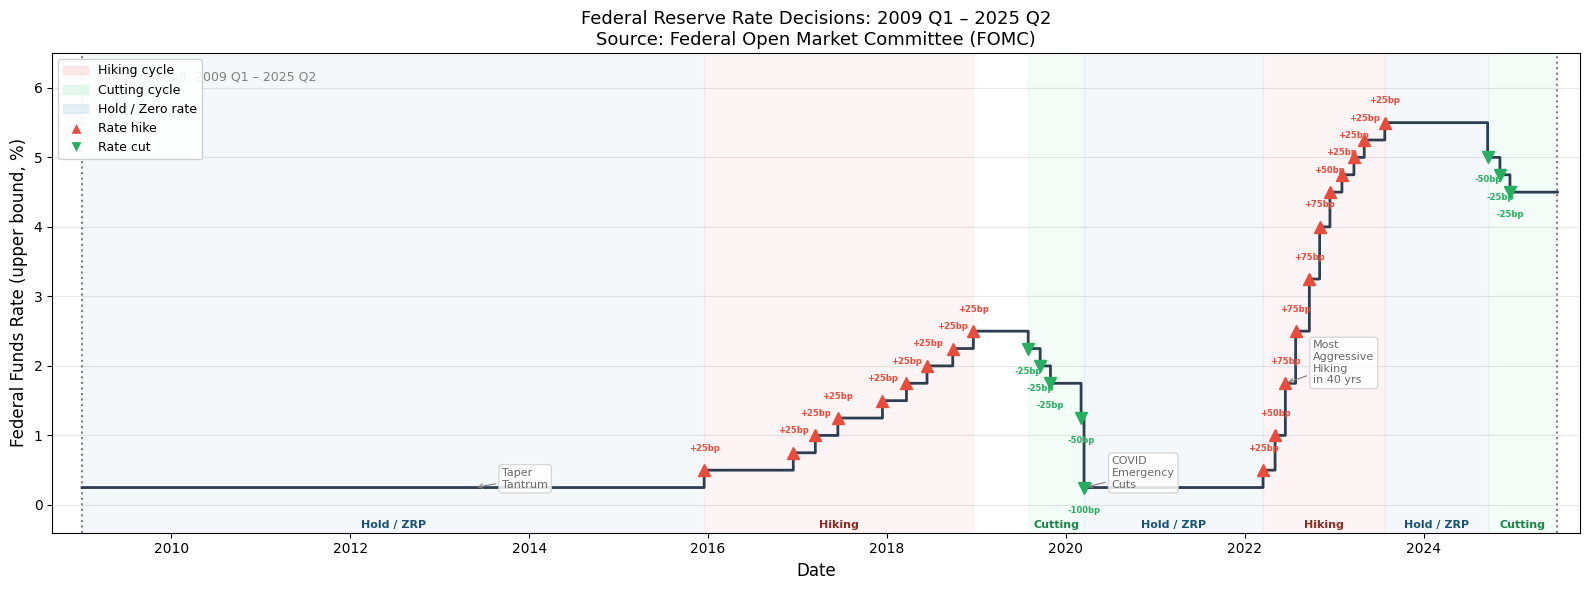

Saved: fed_rate_history.png


In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

# ── 準確的 Fed 利率資料（來源：Wikipedia）────────────────────
fed_moves = [
    # (date, upper_bound_after)
    ('2008-12-16', 0.25),   # 樣本起點前，作為初始值
    ('2015-12-16', 0.50),
    ('2016-12-14', 0.75),
    ('2017-03-14', 1.00),
    ('2017-06-14', 1.25),
    ('2017-12-13', 1.50),
    ('2018-03-21', 1.75),
    ('2018-06-13', 2.00),
    ('2018-09-26', 2.25),
    ('2018-12-19', 2.50),
    ('2019-07-31', 2.25),
    ('2019-09-18', 2.00),
    ('2019-10-30', 1.75),
    ('2020-03-03', 1.25),
    ('2020-03-15', 0.25),
    ('2022-03-16', 0.50),
    ('2022-05-04', 1.00),
    ('2022-06-15', 1.75),
    ('2022-07-27', 2.50),
    ('2022-09-21', 3.25),
    ('2022-11-02', 4.00),
    ('2022-12-14', 4.50),
    ('2023-02-01', 4.75),
    ('2023-03-22', 5.00),
    ('2023-05-03', 5.25),
    ('2023-07-26', 5.50),
    ('2024-09-18', 5.00),
    ('2024-11-07', 4.75),
    ('2024-12-18', 4.50),
]

df_fed = pd.DataFrame(fed_moves, columns=['date', 'rate'])
df_fed['date'] = pd.to_datetime(df_fed['date'])
df_fed['change'] = df_fed['rate'].diff().fillna(0)

# ── 建立逐日利率序列 ─────────────────────────────────────────
date_range = pd.date_range('2009-01-01', '2025-06-30', freq='D')
rate_series = pd.Series(index=date_range, dtype=float)

current_rate = 0.25
for date in date_range:
    moves = df_fed[df_fed['date'] == date]
    if len(moves) > 0:
        current_rate = moves['rate'].values[-1]
    rate_series[date] = current_rate

# ── 週期背景色 ───────────────────────────────────────────────
cycles = [
    ('2009-01-01', '2015-12-16', 'hold'),
    ('2015-12-16', '2018-12-19', 'hike'),
    ('2019-07-31', '2020-03-15', 'cut'),
    ('2020-03-15', '2022-03-16', 'hold'),
    ('2022-03-16', '2023-07-26', 'hike'),
    ('2023-07-26', '2024-09-18', 'hold'),
    ('2024-09-18', '2025-06-30', 'cut'),
]

cycle_colors = {
    'hold': '#d4e6f1',
    'hike': '#fadbd8',
    'cut' : '#d5f5e3',
}

# ── 畫圖 ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))

# 背景色條
for start_d, end_d, direction in cycles:
    ax.axvspan(pd.to_datetime(start_d), pd.to_datetime(end_d),
               alpha=0.25, color=cycle_colors[direction], zorder=0)

# Fed funds rate 走勢
ax.step(rate_series.index, rate_series.values,
        where='post', color='#2c3e50', linewidth=2, zorder=3)

# 每次升降息標注
for _, row in df_fed[df_fed['date'] >= '2009-01-01'].iterrows():
    if row['change'] == 0:
        continue
    is_hike = row['change'] > 0
    color   = '#e74c3c' if is_hike else '#27ae60'
    marker  = '^' if is_hike else 'v'
    change_str = f"+{int(row['change']*100)}" if is_hike else f"{int(row['change']*100)}"

    ax.plot(row['date'], row['rate'],
            marker=marker, color=color,
            markersize=8, zorder=4)

    ax.annotate(f"{change_str}bp",
                xy=(row['date'], row['rate']),
                xytext=(0, 14 if is_hike else -18),
                textcoords='offset points',
                ha='center', fontsize=6,
                color=color, fontweight='bold')

# 週期標籤（底部）
cycle_label_map = {
    'hold': 'Hold / ZRP',
    'hike': 'Hiking',
    'cut' : 'Cutting',
}
for start_d, end_d, direction in cycles:
    mid = pd.to_datetime(start_d) + \
          (pd.to_datetime(end_d) - pd.to_datetime(start_d)) / 2
    label = cycle_label_map[direction]
    ax.text(mid, -0.22, label,
            ha='center', va='top', fontsize=8,
            color={'hold': '#1a5276', 'hike': '#922b21',
                   'cut': '#1e8449'}[direction],
            fontweight='bold')

# 重要事件標注
events = [
    ('2013-05-22', 'Taper\nTantrum', 0.8),
    ('2020-03-15', 'COVID\nEmergency\nCuts', 1.5),
    ('2022-06-15', 'Most\nAggressive\nHiking\nin 40 yrs', 3.5),
]
for date, label, y_pos in events:
    dt = pd.to_datetime(date)
    ax.annotate(label,
                xy=(dt, rate_series[dt]),
                xytext=(20, 0),
                textcoords='offset points',
                ha='left', fontsize=8,
                color='dimgray',
                bbox=dict(boxstyle='round,pad=0.3',
                          fc='white', alpha=0.85, ec='lightgray'),
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

# 樣本區間標記
ax.axvline(pd.to_datetime('2009-01-01'), color='gray',
           linestyle=':', linewidth=1.5)
ax.axvline(pd.to_datetime('2025-06-30'), color='gray',
           linestyle=':', linewidth=1.5)
ax.text(pd.to_datetime('2009-03-01'), 6.1,
        'Sample period: 2009 Q1 – 2025 Q2',
        fontsize=9, color='gray')

# Legend
hike_patch  = mpatches.Patch(color='#fadbd8', alpha=0.6, label='Hiking cycle')
cut_patch   = mpatches.Patch(color='#d5f5e3', alpha=0.6, label='Cutting cycle')
hold_patch  = mpatches.Patch(color='#d4e6f1', alpha=0.6, label='Hold / Zero rate')
hike_marker = plt.Line2D([0], [0], marker='^', color='w',
                          markerfacecolor='#e74c3c',
                          markersize=9, label='Rate hike')
cut_marker  = plt.Line2D([0], [0], marker='v', color='w',
                          markerfacecolor='#27ae60',
                          markersize=9, label='Rate cut')

ax.legend(handles=[hike_patch, cut_patch, hold_patch,
                   hike_marker, cut_marker],
          loc='upper left', fontsize=9, framealpha=0.9)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Federal Funds Rate (upper bound, %)', fontsize=12)
ax.set_title('Federal Reserve Rate Decisions: 2009 Q1 – 2025 Q2\n'
             'Source: Federal Open Market Committee (FOMC)',
             fontsize=13)
ax.set_xlim(pd.to_datetime('2008-09-01'), pd.to_datetime('2025-09-30'))
ax.set_ylim(-0.4, 6.5)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(
    '/Users/yuzetsai/Desktop/Machine Learning on MacroEcon/Data/fed_rate_history.png',
    dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fed_rate_history.png")